### **Actividad Grupal - Análisis de datos**

Tomás Abraham

Diego Anibal Vazquez

---



# **Punto 1**

Exploración y comprensión de los datos:


*   Cargar Dataset y realizar EDA.
*   Describir las características principales del dataset, incluyendo número de observaciones, número de variables y tipos de datos.
* Identificar patrones generales y distribuciones.
* Identificar errores, outliers, valores faltantes y su tipo (MCAR, MAR, MNAR).



importo bibliotecas

In [1]:
import pandas as pd
import numpy as  np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import missingno as msno
from scipy import stats as st
from scipy.stats import describe
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency

levanto el dataset

In [2]:
# Ruta al CSV
file_path = 'datasets/NYPD_Complaint_Data_Current_(Year_To_Date)_20260504.zip'
# Lectura del CSV y creación del dataframe
df = pd.read_csv(file_path)

In [3]:
#Establece la opción para mostrar todas las columnas (si no muestra sólo 20)
pd.set_option('display.max_columns', None)
display(df.head(15))

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PARKS_NM,PATROL_BORO,PD_CD,PD_DESC,PREM_TYP_DESC,RPT_DT,STATION_NAME,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,322232997,60,BROOKLYN,03/01/2026,10:00:00,03/13/2026,00:00:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,340,MISDEMEANOR,INSIDE,FRAUDS,(null),PATROL BORO BKLYN SOUTH,718.0,"FRAUD,UNCLASSIFIED-MISDEMEANOR",RESIDENCE-HOUSE,03/21/2026,(null),UNKNOWN,UNKNOWN,U,NaN,25-44,WHITE,M,995229,149429,"40,576826","-73,960478","(40.576826, -73.960478)",POINT (-73.960478 40.576826)
1,319667320,61,BROOKLYN,01/30/2026,14:00:00,01/30/2026,14:05:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,344,MISDEMEANOR,INSIDE,ASSAULT 3 & RELATED OFFENSES,(null),PATROL BORO BKLYN SOUTH,101.0,ASSAULT 3,PUBLIC SCHOOL,01/30/2026,(null),<18,WHITE,M,NaN,<18,WHITE,M,998516,161667,"40,610414","-73,948619","(40.610414, -73.948619)",POINT (-73.948619 40.610414)
2,319668752,47,BRONX,01/30/2026,22:25:00,01/30/2026,22:30:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,113,FELONY,(null),FORGERY,(null),PATROL BORO BRONX,725.0,"FORGERY,M.V. REGISTRATION",STREET,01/30/2026,(null),25-44,BLACK,F,NaN,UNKNOWN,UNKNOWN,E,1025119,268754,"40,9042464","-73,85215489","(40.9042464, -73.85215489)",POINT (-73.85215489 40.9042464)
3,322203999,122,STATEN ISLAND,03/21/2026,03:15:00,03/21/2026,03:20:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,578,VIOLATION,FRONT OF,HARRASSMENT 2,(null),PATROL BORO STATEN ISLAND,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE-HOUSE,03/21/2026,(null),UNKNOWN,UNKNOWN,U,NaN,45-64,WHITE,M,938726,139994,"40,55082","-74,163815","(40.55082, -74.163815)",POINT (-74.163815 40.55082)
4,322235003,123,STATEN ISLAND,03/22/2026,20:30:00,03/22/2026,20:50:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,344,MISDEMEANOR,INSIDE,ASSAULT 3 & RELATED OFFENSES,(null),PATROL BORO STATEN ISLAND,101.0,ASSAULT 3,RESIDENCE-HOUSE,03/22/2026,(null),25-44,WHITE HISPANIC,M,NaN,25-44,WHITE HISPANIC,F,934395,143898,"40,561512","-74,179427","(40.561512, -74.179427)",POINT (-74.179427 40.561512)
5,322360334,123,STATEN ISLAND,03/25/2026,03:00:00,03/25/2026,03:20:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,348,MISDEMEANOR,(null),VEHICLE AND TRAFFIC LAWS,(null),PATROL BORO STATEN ISLAND,922.0,"TRAFFIC,UNCLASSIFIED MISDEMEAN",STREET,03/25/2026,(null),45-64,WHITE,M,NaN,UNKNOWN,UNKNOWN,E,922746,139826,"40,55025242","-74,22131435","(40.55025242, -74.22131435)",POINT (-74.22131435 40.55025242)
6,322705295,121,STATEN ISLAND,03/31/2026,19:50:00,03/31/2026,20:00:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,126,FELONY,INSIDE,MISCELLANEOUS PENAL LAW,(null),PATROL BORO STATEN ISLAND,198.0,CRIMINAL CONTEMPT 1,RESIDENCE-HOUSE,03/31/2026,(null),45-64,WHITE,M,NaN,25-44,WHITE,F,939956,161133,"40,608848","-74,159526","(40.608848, -74.159526)",POINT (-74.159526 40.608848)
7,322088066,121,STATEN ISLAND,03/19/2026,15:25:00,03/19/2026,16:05:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,348,MISDEMEANOR,FRONT OF,VEHICLE AND TRAFFIC LAWS,(null),PATROL BORO STATEN ISLAND,922.0,"TRAFFIC,UNCLASSIFIED MISDEMEAN",STREET,03/19/2026,(null),45-64,WHITE,M,NaN,UNKNOWN,UNKNOWN,E,943977,153740,"40,588575","-74,145002","(40.588575, -74.145002)",POINT (-74.145002 40.588575)
8,321529381,101,QUEENS,03/09/2026,10:40:00,03/09/2026,10:43:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,341,MISDEMEANOR,FRONT OF,PETIT LARCENY,(null),PATROL BORO QUEENS SOUTH,338.0,"LARCENY,PETIT FROM BUILDING,UN",RESIDENCE - APT. HOUSE,03/09/2026,(null),25-44,BLACK,F,NaN,25-44,BLACK,M,1044590,156200,"40,595214","-73,782726","(40.595214, -73.782726)",POINT (-73.782726 40.595214)
9,318700273,120,STATEN ISLAND,01/10/2026,10:00:00,01/10/2026,15:34:00,COMPLETED,(null),NaN,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,(null),PATROL BORO STATEN ISLAND,307.0,"LARCENY,PETIT BY D

Solo vamos a usar los casos del 2025 (lo pide el tp)

In [124]:
df = df[
    df['CMPLNT_FR_DT'].str.endswith('2025', na=False)
]
display(df.head(15))

KeyError: 'CMPLNT_FR_DT'

Cantidad de filas y columnas

In [ ]:
df.shape

(5939, 36)

Pantallazo de columnas, cuenta de no nulls y tipos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CMPLNT_NUM                5939 non-null   object 
 1   ADDR_PCT_CD               5939 non-null   int64  
 2   BORO_NM                   5939 non-null   object 
 3   CMPLNT_FR_DT              5939 non-null   object 
 4   CMPLNT_FR_TM              5939 non-null   object 
 5   CMPLNT_TO_DT              5579 non-null   object 
 6   CMPLNT_TO_TM              5939 non-null   object 
 7   CRM_ATPT_CPTD_CD          5939 non-null   object 
 8   HADEVELOPT                5939 non-null   object 
 9   HOUSING_PSA               323 non-null    float64
 10  JURISDICTION_CODE         5939 non-null   int64  
 11  JURIS_DESC                5939 non-null   object 
 12  KY_CD                     5939 non-null   int64  
 13  LAW_CAT_CD                5939 non-null   object 
 14  LOC_OF_OCC

In [ ]:
delito_cat_nom = [
    'BORO_NM',
    'CRM_ATPT_CPTD_CD',
    'HADEVELOPT',
    'JURIS_DESC',
    'LAW_CAT_CD',
    'OFNS_DESC',
    'PATROL_BORO',
    'KY_CD',
    'PD_CD',
    'PD_DESC',
    'PREM_TYP_DESC',
    'SUSP_RACE',
    'SUSP_SEX',
    'VIC_RACE',
    'VIC_SEX',
    'ADDR_PCT_CD',
    'HOUSING_PSA',
    'JURISDICTION_CODE',
    'LOC_OF_OCCUR_DESC',
    'PARKS_NM',
    'STATION_NAME',
    'SUSP_AGE_GROUP',
    'TRANSIT_DISTRICT',
    'VIC_AGE_GROUP'
]#delito_cat_num= ['ADDR_PCT_CD', 'ADDR_PCT_CD','sibsp', 'parch']
dtype_map ={col: 'category' for col in delito_cat_nom}

df = df.astype(dtype_map)
# Aplicamos el mapping al DataFrame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   CMPLNT_NUM                5939 non-null   object  
 1   ADDR_PCT_CD               5939 non-null   category
 2   BORO_NM                   5939 non-null   category
 3   CMPLNT_FR_DT              5939 non-null   object  
 4   CMPLNT_FR_TM              5939 non-null   object  
 5   CMPLNT_TO_DT              5579 non-null   object  
 6   CMPLNT_TO_TM              5939 non-null   object  
 7   CRM_ATPT_CPTD_CD          5939 non-null   category
 8   HADEVELOPT                5939 non-null   category
 9   HOUSING_PSA               323 non-null    category
 10  JURISDICTION_CODE         5939 non-null   category
 11  JURIS_DESC                5939 non-null   category
 12  KY_CD                     5939 non-null   category
 13  LAW_CAT_CD                5939 non-null   category

de esta información y de la fuente podemos determinar:

N° | Column Name              | API Field | Data Type           | Description
---|--------------------------|-----------|---------------------|------------
1  | CMPLNT_NUM              | cmplnt_num| Text                | Identificador único de la denuncia
2  | ADDR_PCT_CD             | addr_pct_cd| Numeric             | Precinto donde ocurrió el incidente
3  | BORO_NM                 | boro_nm   | Text                | Borough donde ocurrió el incidente
4  | CMPLNT_FR_DT            | cmplnt_fr_dt| Date                | Fecha de inicio del incidente
5  | CMPLNT_FR_TM            | cmplnt_fr_tm| Time (Text)         | Hora de inicio del incidente
6  | CMPLNT_TO_DT            | cmplnt_to_dt| Date                | Fecha de fin del incidente
7  | CMPLNT_TO_TM            | cmplnt_to_tm| Time (Text)         | Hora de fin del incidente
8  | CRM_ATPT_CPTD_CD        | crm_atpt_cptd_cd| Text                | Indica si el delito fue consumado o intentado
9  | HADEVELOPT              | hadevelopt| Text                | Complejo habitacional (si aplica)
10 | HOUSING_PSA             | housing_psa| Numeric             | Código de área de vivienda
11 | JURISDICTION_CODE       | jurisdiction_code| Numeric             | Código de jurisdicción
12 | JURIS_DESC              | juris_desc| Text                | Descripción de la jurisdicción
13 | KY_CD                   | ky_cd     | Numeric             | Código general del delito
14 | LAW_CAT_CD              | law_cat_cd| Text                | Nivel del delito (felony/misdemeanor/violation)
15 | LOC_OF_OCCUR_DESC       | loc_of_occur_desc| Text                | Ubicación relativa del hecho
16 | OFNS_DESC               | ofns_desc | Text                | Descripción del delito
17 | PARKS_NM                | parks_nm  | Text                | Nombre del parque (si aplica)
18 | PATROL_BORO             | patrol_boro| Text                | Zona de patrullaje
19 | PD_CD                   | pd_cd     | Numeric             | Código interno del delito
20 | PD_DESC                 | pd_desc   | Text                | Descripción detallada del delito
21 | PREM_TYP_DESC           | prem_typ_desc| Text                | Tipo de establecimiento
22 | RPT_DT                  | rpt_dt    | Date                | Fecha de reporte
23 | STATION_NAME            | station_name| Text                | Estación de tránsito
24 | SUSP_AGE_GROUP          | susp_age_group| Text                | Edad del sospechoso
25 | SUSP_RACE               | susp_race | Text                | Raza del sospechoso
26 | SUSP_SEX                | susp_sex  | Text                | Sexo del sospechoso
27 | TRANSIT_DISTRICT        | transit_district| Numeric             | Distrito de tránsito
28 | VIC_AGE_GROUP           | vic_age_group| Text                | Edad de la víctima
29 | VIC_RACE                | vic_race  | Text                | Raza de la víctima
30 | VIC_SEX                 | vic_sex   | Text                | Sexo de la víctima
31 | X_COORD_CD              | x_coord_cd| Numeric             | Coordenada X (sistema estatal)
32 | Y_COORD_CD              | y_coord_cd| Numeric             | Coordenada Y (sistema estatal)
33 | Latitude                | latitude  | Numeric (latitude)  | Latitud geográfica
34 | Longitude               | longitude | Numeric (longitude) | Longitud geográfica
35 | Lat_Lon                 | lat_lon   | Point               | Coordenadas combinadas
36 | New Georeferenced Column| new_georeferenced_column| Point               | Punto georreferenciado


Identifico error en nulles y hago replace porque hay atributos donde el null esta expresado de forma distinta, asi que unifico y homogeneizar distintas representaciones de valores faltantes


In [ ]:
df = df.replace([
    'NULL', 'null', '(null)', 'NaN', 'N/A', 'na', 'NA', '', ' '
], np.nan)

# también limpiar strings con espacios
df = df.replace(r'^\s*$', np.nan, regex=True)

/tmp/ipykernel_174662/836765493.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace([


reviso de vuelta info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   CMPLNT_NUM                5939 non-null   object  
 1   ADDR_PCT_CD               5939 non-null   category
 2   BORO_NM                   5884 non-null   category
 3   CMPLNT_FR_DT              5939 non-null   object  
 4   CMPLNT_FR_TM              5939 non-null   object  
 5   CMPLNT_TO_DT              5579 non-null   object  
 6   CMPLNT_TO_TM              5575 non-null   object  
 7   CRM_ATPT_CPTD_CD          5939 non-null   category
 8   HADEVELOPT                16 non-null     category
 9   HOUSING_PSA               323 non-null    category
 10  JURISDICTION_CODE         5939 non-null   category
 11  JURIS_DESC                5939 non-null   category
 12  KY_CD                     5939 non-null   category
 13  LAW_CAT_CD                5939 non-null   category

Tipos de variables del dataset y descripción

| Columna | Tipo de dato | Qué representa |
|----------|-------------|----------------|
| CMPLNT_NUM | Identificador (object) | ID único del incidente |
| ADDR_PCT_CD | Categórica | Precinto policial del incidente |
| BORO_NM | Categórica | Borough donde ocurrió el hecho |
| CMPLNT_FR_DT | Temporal (object) | Fecha de inicio del incidente |
| CMPLNT_FR_TM | Temporal (object) | Hora de inicio del incidente |
| CMPLNT_TO_DT | Temporal (object) | Fecha de fin del incidente |
| CMPLNT_TO_TM | Temporal (object) | Hora de fin del incidente |
| CRM_ATPT_CPTD_CD | Categórica | Indica si el delito fue consumado o intentado |
| HADEVELOPT | Categórica  | Desarrollo habitacional donde ocurrió el hecho |
| HOUSING_PSA | Categórica | Área de seguridad de vivienda pública |
| JURISDICTION_CODE | Categórica numérica | Código de jurisdicción del hecho |
| JURIS_DESC | Categórica | Descripción de la jurisdicción (policía, tránsito, etc.) |
| KY_CD | Categórica numérica | Código de categoría del delito |
| LAW_CAT_CD | Categórica | Nivel legal del delito (felony, misdemeanor, violation) |
| LOC_OF_OCCUR_DESC | Categórica | Ubicación específica del hecho |
| OFNS_DESC | Categórica | Descripción del tipo de delito |
| PARKS_NM | Categórica | Nombre del parque donde ocurrió el hecho |
| PATROL_BORO | Categórica | División de patrullaje policial |
| PD_CD | Categórica numérica | Código del delito (Police Department Code) |
| PD_DESC | Categórica | Descripción del código del delito |
| PREM_TYP_DESC | Categórica | Tipo de establecimiento donde ocurrió el hecho |
| RPT_DT | Temporal (object) | Fecha de reporte del incidente |
| STATION_NAME | Categórica (contextual) | Estación de transporte asociada al hecho |
| SUSP_AGE_GROUP | Categórica | Grupo etario del sospechoso |
| SUSP_RACE | Categórica | Raza del sospechoso |
| SUSP_SEX | Categórica | Sexo del sospechoso |
| TRANSIT_DISTRICT | Categórica  | Distrito de transporte asociado al hecho |
| VIC_AGE_GROUP | Categórica | Grupo etario de la víctima |
| VIC_RACE | Categórica | Raza de la víctima |
| VIC_SEX | Categórica | Sexo de la víctima |
| X_COORD_CD | Numérica | Coordenada X del hecho |
| Y_COORD_CD | Numérica | Coordenada Y del hecho |
| Latitude | Numérica (object) | Latitud geográfica |
| Longitude | Numérica (object) | Longitud geográfica |
| Lat_Lon | Geográfica (object) | Coordenada combinada |
| New Georeferenced Column | Geográfica (object) | Geolocalización en formato estructurado |

Verifico si hay valores dups

In [ ]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 0


Funcion para ver faltantes

In [ ]:
def valores_faltante_tabla(df):
        # Total valores falantes
        mis_val = df.isnull().sum()

        # Percentaje de valores faltantes
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        #
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # renombramos las columnas
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Valores faltantes ', 1 : '% de Total de valores'})

        # Ordenar la tabla por porcentaje de faltantes descendentes
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% de Total de valores', ascending=False).round(1)

        # Imprimimos un resumen
        print ("el dataframe tiene " + str(df.shape[1]) + " columnas.\n"
            " y hay " + str(mis_val_table_ren_columns.shape[0]) +
              " columnas con valores faltantes.")

        # devolvemos la informacion
        return mis_val_table_ren_columns

Listo los porcentajes de faltantes por atributo

In [14]:
valores_faltante_tabla(df)

el dataframe tiene 36 columnas.
 y hay 16 columnas con valores faltantes.


,Valores faltantes,% de Total de valores
HADEVELOPT,5923,99.7
PARKS_NM,5915,99.6
STATION_NAME,5849,98.5
TRANSIT_DISTRICT,5849,98.5
HOUSING_PSA,5616,94.6
SUSP_AGE_GROUP,1140,19.2
SUSP_RACE,1140,19.2
SUSP_SEX,1140,19.2
LOC_OF_OCCUR_DESC,633,10.7
CMPLNT_TO_TM,364,6.1


<Axes: >

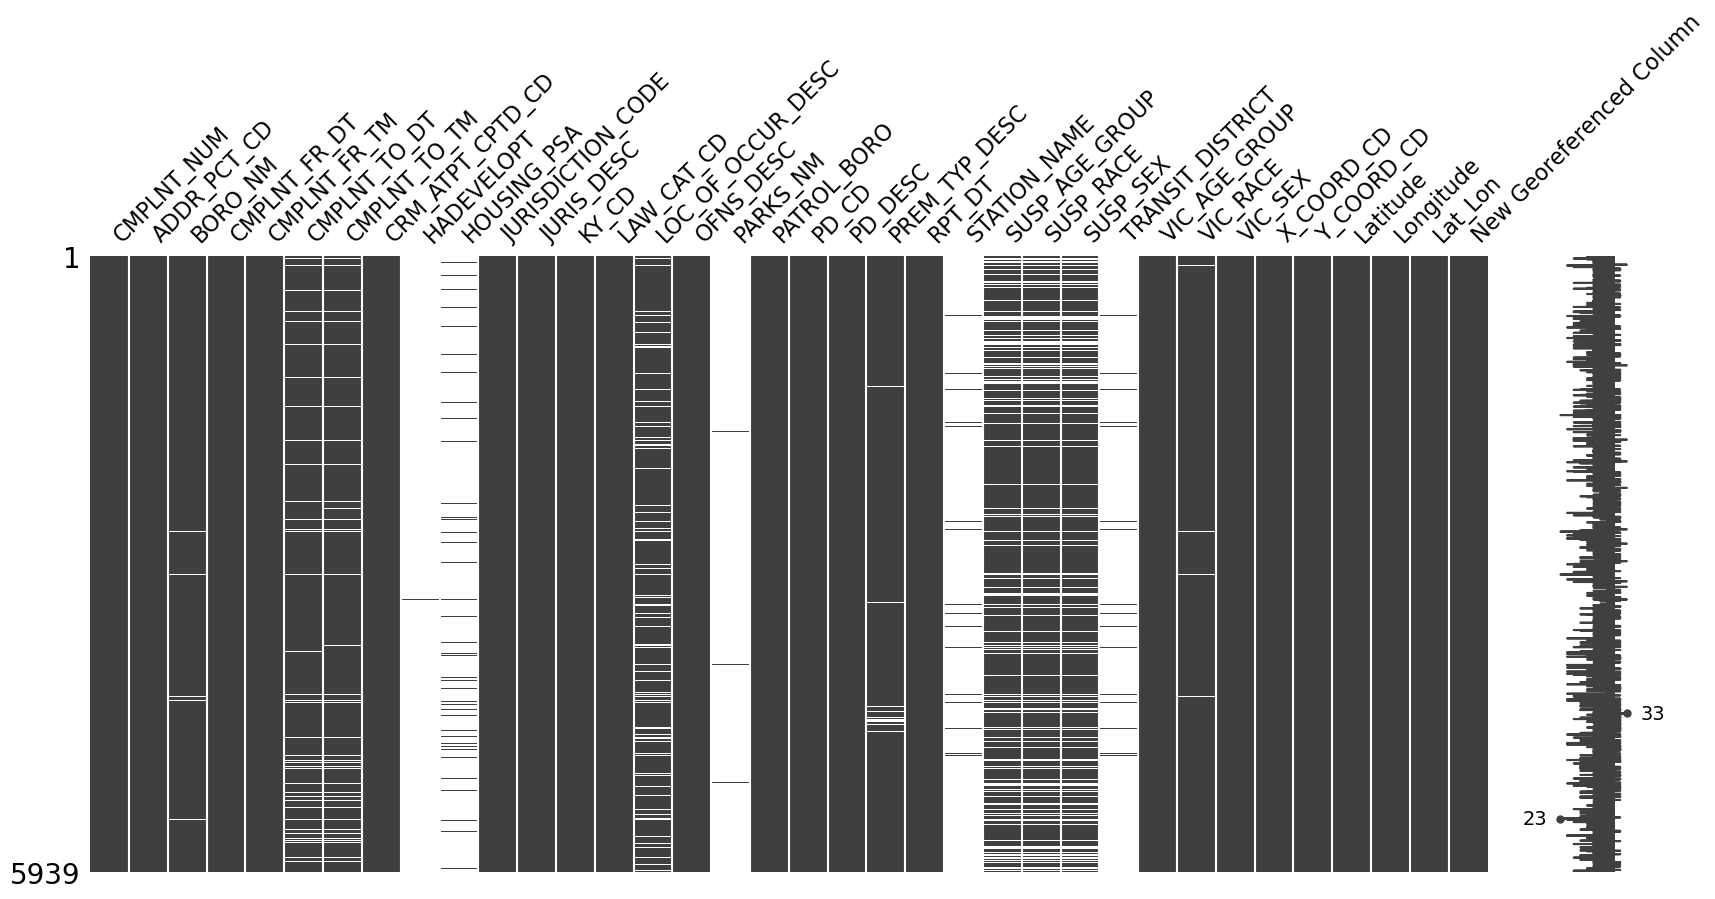

In [15]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

Aca podemos ver que HADEVELOPT, PARKS_NM, TRANSIT_DISTRICT, STATION_NAME, HOUSING_PSA	son los que mas portentaje de nulos, se puede considerar eliminar estas columnas, falta hacer la clasificacion de los tipos de nulos.


Text(0.5, 1.0, 'Correlación de datos nulos')

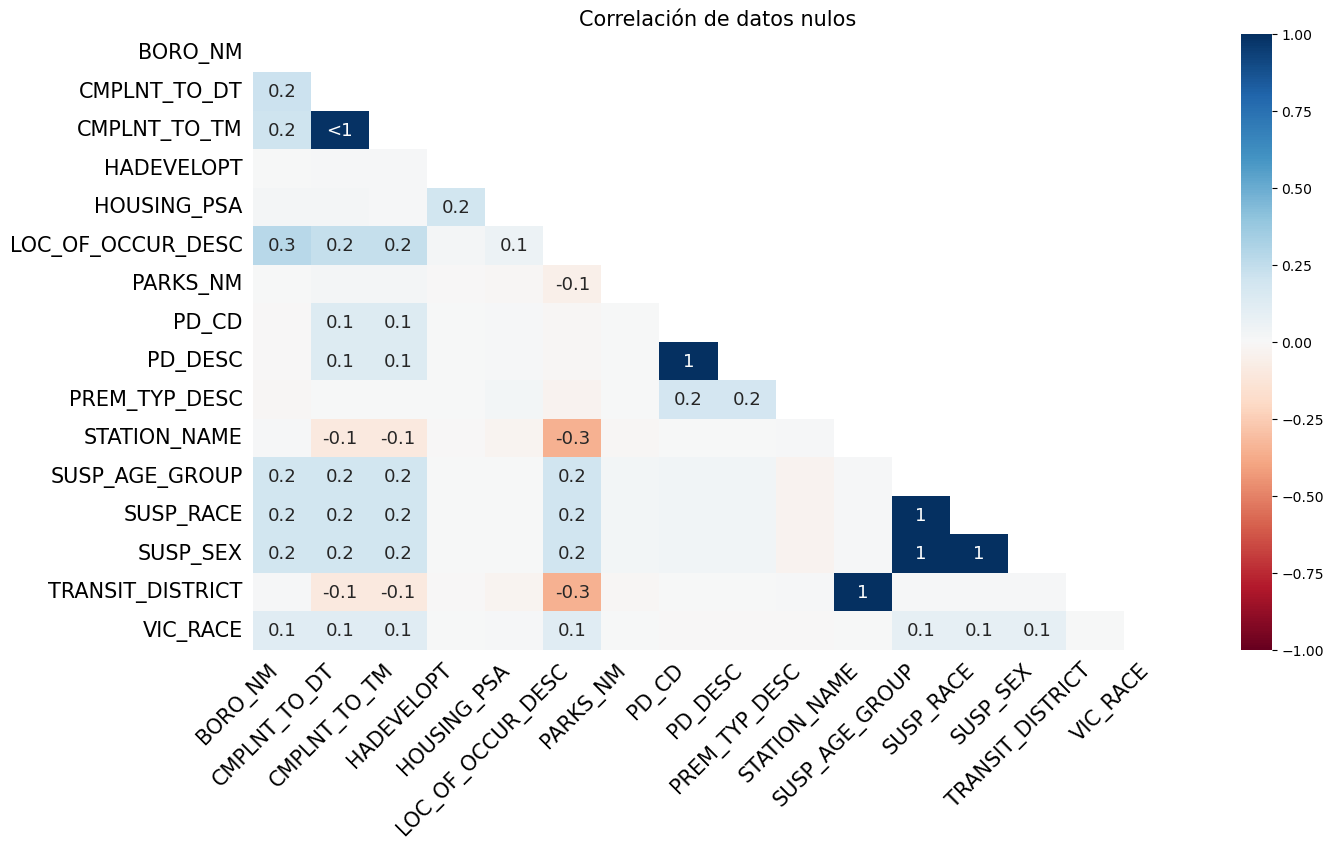

In [16]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)

La correlación entre los valores nulos de las distintas variables con el objetivo de identificar patrones de ausencia conjunta de información. La mayoría de las correlaciones observadas fueron bajas (entre -0.3 y 0.3), lo que dice que los datos faltantes se distribuyen de manera relativamente independiente entre las variables.
Se identificaron algunos casos de correlación muy alta entre los faltantes. Las variables PD_CD y PD_DESC presentan una correlación cercana a 1.  También se observaron correlaciones prácticamente perfectas entre los faltantes de SUSP_AGE_GROUP, SUSP_RACE y SUSP_SEX, lo que indica que la información del sospechoso suele estar disponible o ausente de forma conjunta. Un patrón similar se observa entre SUSP_AGE_GROUP y TRANSIT_DISTRICT.
Algunas variables presentan correlaciones negativas moderadas, como LOC_OF_OCCUR_DESC con STATION_NAME y TRANSIT_DISTRICT (≈ -0.3), lo que indica que la ausencia de información en una variable tiende a coincidir con la presencia de información en la otra.

dendrograma de patrones de valores faltantes

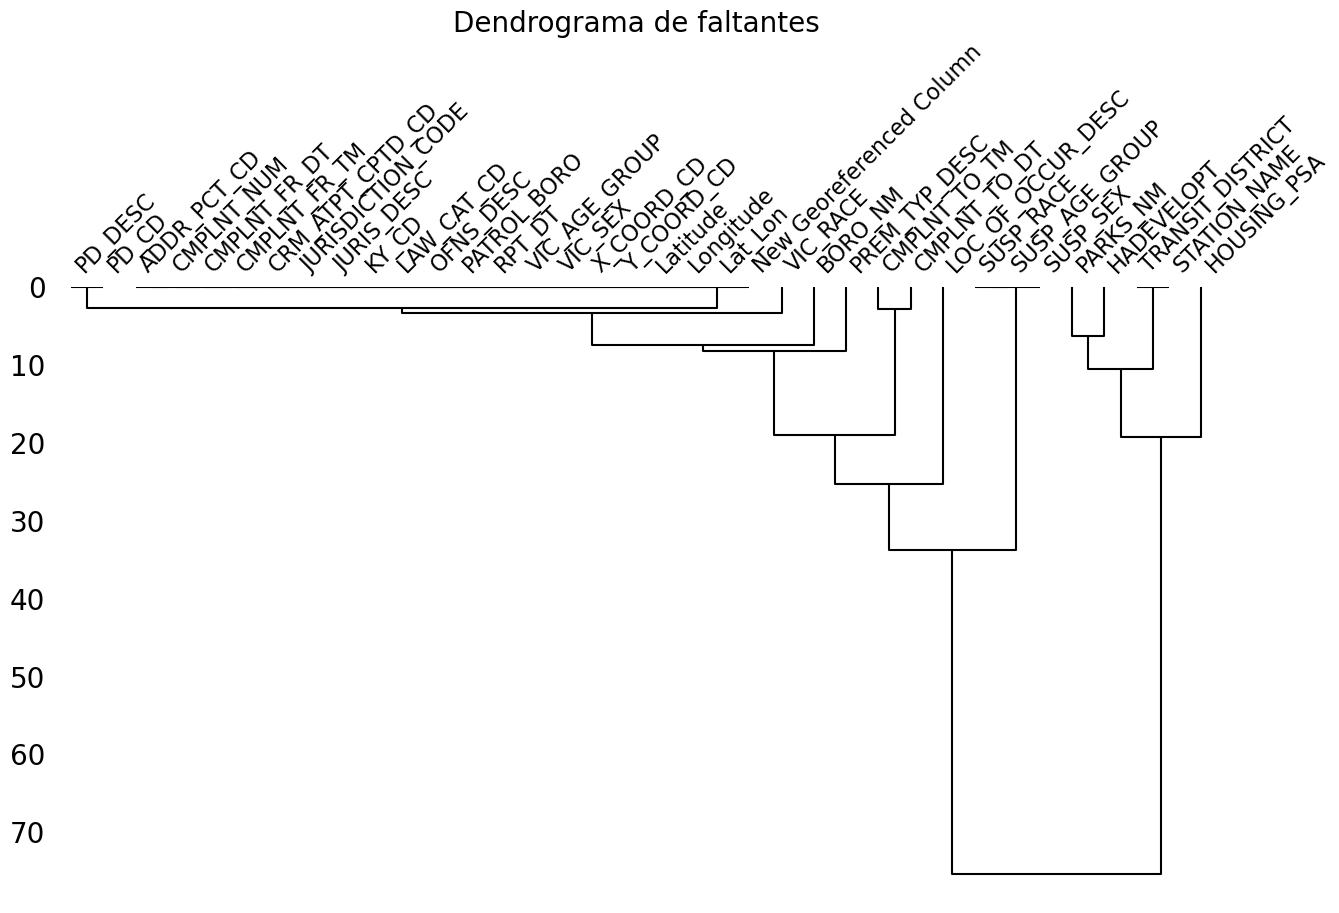

In [17]:
msno.dendrogram(df, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

Analisis:
grupo 1: grupo de variables prácticamente sin faltantes

A la izquierda aparece un gran conjunto:

PD_DESC
PD_CD
ADDR_PCT_CD
CMPLNT_FR_DT
CMPLNT_FR_TM
CMPLNT_TO_DT
JURISDICTION_CODE
KY_CD
LAW_CAT_CD
OFNS_DESC
PATROL_BORO
RPT_DT
VIC_AGE_GROUP
VIC_SEX
X_COORD_CD
Y_COORD_CD
Latitude
Longitude
Lat_Lon
New Georeferenced Column

entonces,

Interpretación:

Constituyen el bloque principal del dendrograma.
Presentan muy pocos valores faltantes o patrones de ausencia similares.
Los registros donde faltan datos en estas variables tienden a coincidir.
Desde el punto de vista de calidad de datos, corresponden a las variables más completas y consistentes del conjunto de datos.
Las variables geográficas (Latitude, Longitude, X_COORD_CD, Y_COORD_CD, Lat_Lon) muestran además una fuerte similitud entre sí, lo que es esperable dado que representan distintas formas de registrar la ubicación del incidente.

grupo 2:
BORO_NM
PREM_TYP_DESC
CMPLNT_TO_TM
LOC_OF_OCCUR_DESC

Presentan un patrón de faltantes diferente al bloque principal.
La ausencia de información en estas variables suele producirse conjuntamente.
Esto sugiere que determinados registros carecen simultáneamente de información contextual sobre el lugar o las características del hecho.
Constituyen un mecanismo de faltantes diferenciado respecto de las variables principales.

Grupo 3:
SUSP_RACE
SUSP_AGE_GROUP
SUSP_SEX
Interpretación:

Forman uno de los grupos más claramente definidos del dendrograma.
Cuando falta información de una de estas variables, normalmente faltan también las demás.
Esto sugiere que la ausencia de información del sospechoso responde a una causa común, posiblemente vinculada a incidentes en los que el sospechoso no fue identificado o no se registraron sus características.

Grupo 4:
PARKS_NM
HADEVELOPT
TRANSIT_DISTRICT
STATION_NAME
HOUSING_PSA

Constituyen el grupo más diferenciado del dendrograma.
Presentan un patrón de faltantes muy distinto al resto de las variables.
Probablemente se debe a que sólo son aplicables en contextos específicos (parques, estaciones, transporte público o complejos habitacionales).
Por lo tanto, permanecen vacías en la mayoría de los registros y sólo se completan cuando el incidente ocurre en dichos ámbitos.

**Clasificacion de nulos**

**para recordar:**

MCAR: la falta del dato es aleatoria y no depende de ninguna variable.

MAR: la falta del dato depende de otras variables observadas.

MNAR: la falta del dato depende del dato en sí mismo.

Estructural: no es realmente un faltante, sino un dato que no existe.

Si el porcentaje de nulos es parecido en todos los grupos → podría ser MCAR.

Si cambia mucho entre grupos → probablemente MAR.

Si descubrís que la variable solo aplica a ciertos registros → Estructural.



Voy a dividir mis varibles por grupo x cantidad de nulos:







1.   Con la mayor cantidad de nulos:


| Variable         | % nulos |
| ---------------- | ------- |
| HADEVELOPT       | 99.7    |
| PARKS_NM         | 99.6    |
| TRANSIT_DISTRICT | 98.5    |
| STATION_NAME     | 98.5    |
| HOUSING_PSA      | 94.6    |


STATION_NAME ¿Todos los delitos ocurren en una estación?
No, posiblemente sea estructural

In [18]:
print(df['STATION_NAME'].value_counts(dropna=False).head(20))

STATION_NAME
NaN                               5849
50 STREET                            8
49 STREET                            5
ROOSEVELT AVE.-JACKSON HEIGHTS       5
170 STREET                           4
WYCKOFF AVENUE                       4
FORDHAM ROAD                         4
21 ST.-QUEENSBRIDGE                  3
23 STREET                            3
125 STREET                           2
42 STREET                            2
BROADWAY-EAST NEW YORK               2
42 ST.-TIMES SQUARE                  2
96TH STREET                          2
EAST 180 STREET                      2
W. 4 STREET                          2
HUNTS POINT AVENUE                   1
HOUSTON STREET                       1
GRAND ARMY PLAZA                     1
JUNIUS STREET                        1
Name: count, dtype: int64


Son estaciones, se confirma que es estructural, ya que los delitos no se dan siempre en estaciones

HADEVELOPT ¿Todos los delitos ocurren en desarrollos habitacionales?
No, posiblemente sea estructural

In [19]:
print(df['HADEVELOPT'].value_counts(dropna=False).head(20))

HADEVELOPT
NaN                                5923
INGERSOLL                             2
RIIS                                  2
WOODSIDE                              2
CAMPOS PLAZA I                        1
GLENWOOD                              1
GRANT                                 1
LOWER EAST SIDE REHAB (GROUP 5)       1
MARKHAM GARDENS                       1
NOSTRAND                              1
RIIS II                               1
SMITH                                 1
WHITMAN                               1
WILLIAMSBURG                          1
Name: count, dtype: int64


Estructural, los delitos no se dan en desarrollos habitacionales.



PARKS_NM  ¿Todos los delitos ocurren en parques?
No, posiblemente sea estructural

In [20]:
print(df['PARKS_NM'].value_counts(dropna=False).head(20))

PARKS_NM
NaN                              5915
SARA D. ROOSEVELT PARK              5
CENTRAL PARK                        2
UNION SQUARE PARK                   1
THOMAS JEFFERSON PARK               1
STARLIGHT PARK                      1
ST. MARY'S PARK BRONX               1
SOUNDVIEW PARK                      1
QUEENSBRIDGE PARK                   1
MILL POND PARK                      1
BROOKLYN BRIDGE PARK                1
HUDSON RIVER PARK                   1
HAWKINS PARK                        1
GREENBELT NATIVE PLANT CENTER       1
GREELEY SQUARE PARK                 1
FLUSHING MEADOWS CORONA PARK        1
CLOVE LAKES PARK                    1
CLAREMONT PARK                      1
CHARLTON GARDEN                     1
LEIF ERICSON PARK                   1
Name: count, dtype: int64


Se confirma es estructural.

HOUSING_PSA los delitos ocurren en viviendas publicas?
No, posiblemente sea estructural.


In [21]:
print(df['HOUSING_PSA'].value_counts(dropna=False).head(20))

HOUSING_PSA
NaN         5616
 73252.0       8
 887.0         7
 339.0         7
 638.0         6
 1251.0        6
 664.0         6
 1269.0        6
 1193.0        5
 590.0         5
 672.0         5
 720.0         5
 463.0         5
 632.0         5
 227.0         5
 897.0         4
 73631.0       4
 845.0         4
 811.0         4
 365.0         4
Name: count, dtype: int64


Aca esta mas dificil  porque no se que son esos números pero suena estructural.


TRANSIT_DISTRICT ¿Todos los delitos ocurren en transporte?
Sospecho que sea estructural


In [22]:
print(df['TRANSIT_DISTRICT'].value_counts(dropna=False).head(20))

TRANSIT_DISTRICT
NaN      5849
 1.0       22
 11.0      10
 20.0      10
 33.0      10
 2.0        8
 4.0        8
 32.0       8
 12.0       6
 34.0       6
 3.0        1
 30.0       1
Name: count, dtype: int64


Parece confirmarse que también es estructural

2.   Analizo los que estan entre 10 y 20 por ciento



| Variable          | % nulos |
| ----------------- | ------- |
| SUSP_RACE         | 19.2    |
| SUSP_AGE_GROUP    | 19.2    |
| SUSP_SEX          | 19.2    |
| LOC_OF_OCCUR_DESC | 10.7    |


Todo sospechoso debería tener sexo, edad y raza registrados.

In [23]:
# Creamos una función para calcular el porcentaje de nulos en una columna, agrupando por una o más columnas
def nulos_por_grupo(df, grupo_cols, target_col):
    agrupar_nulos = (
        df.groupby(grupo_cols, observed=True)[target_col]
        .apply(lambda x: x.isnull().mean() * 100)
        .reset_index(name=f'porcentaje_nulos_{target_col}')
    )
    return agrupar_nulos

In [24]:
nulos_por_grupo(df,'BORO_NM','SUSP_RACE')

,BORO_NM,porcentaje_nulos_SUSP_RACE
0,BRONX,21.905537
1,BROOKLYN,22.415865
2,MANHATTAN,11.607143
3,QUEENS,17.444365
4,STATEN ISLAND,17.647059


Apunta a MAR, porque BRONX y BROOKLYN parecen los BORO que tiene mas nulos, para que sea MCAR, deberían ser parecidas las proporciones.

In [25]:
nulos_por_grupo(df,'LAW_CAT_CD','SUSP_RACE')

,LAW_CAT_CD,porcentaje_nulos_SUSP_RACE
0,FELONY,18.750000
1,MISDEMEANOR,22.746331
2,VIOLATION,5.760709


Apunta a MAR, porque FELONY y MISDEMEANOR parecen los LAW_CAT_CD que tiene mas nulos, para que sea MCAR, deberían ser parecidas las proporciones.

In [26]:
nulos_por_grupo(df,'BORO_NM','SUSP_AGE_GROUP')

,BORO_NM,porcentaje_nulos_SUSP_AGE_GROUP
0,BRONX,21.905537
1,BROOKLYN,22.415865
2,MANHATTAN,11.607143
3,QUEENS,17.444365
4,STATEN ISLAND,17.647059


MAR como antes.

In [27]:
nulos_por_grupo(df,'LAW_CAT_CD','SUSP_AGE_GROUP')

,LAW_CAT_CD,porcentaje_nulos_SUSP_AGE_GROUP
0,FELONY,18.750000
1,MISDEMEANOR,22.746331
2,VIOLATION,5.760709


MAR como antes, no parece MCAR

In [28]:
nulos_por_grupo(df,'BORO_NM','SUSP_AGE_GROUP')

,BORO_NM,porcentaje_nulos_SUSP_AGE_GROUP
0,BRONX,21.905537
1,BROOKLYN,22.415865
2,MANHATTAN,11.607143
3,QUEENS,17.444365
4,STATEN ISLAND,17.647059


MAR identico

In [29]:
nulos_por_grupo(df,'BORO_NM','SUSP_SEX')

,BORO_NM,porcentaje_nulos_SUSP_SEX
0,BRONX,21.905537
1,BROOKLYN,22.415865
2,MANHATTAN,11.607143
3,QUEENS,17.444365
4,STATEN ISLAND,17.647059


MAR

In [30]:
nulos_por_grupo(df,'LAW_CAT_CD','SUSP_SEX')

,LAW_CAT_CD,porcentaje_nulos_SUSP_SEX
0,FELONY,18.750000
1,MISDEMEANOR,22.746331
2,VIOLATION,5.760709


MAR

In [31]:
nulos_por_grupo(df,'LAW_CAT_CD','LOC_OF_OCCUR_DESC')

,LAW_CAT_CD,porcentaje_nulos_LOC_OF_OCCUR_DESC
0,FELONY,6.500000
1,MISDEMEANOR,15.199161
2,VIOLATION,6.203840


MAR, mas incidencia en misdemeanor

In [32]:
nulos_por_grupo(df,'BORO_NM','LOC_OF_OCCUR_DESC')

,BORO_NM,porcentaje_nulos_LOC_OF_OCCUR_DESC
0,BRONX,10.667752
1,BROOKLYN,10.336538
2,MANHATTAN,9.226190
3,QUEENS,9.404164
4,STATEN ISLAND,8.235294


Compatible con MCAR, pero ya vi que es MAR

In [33]:

nulos_por_grupo(df, 'JURIS_DESC', 'CMPLNT_TO_TM')

,JURIS_DESC,porcentaje_nulos_CMPLNT_TO_TM
0,AMTRACK,0.000000
1,DEPT OF CORRECTIONS,0.000000
2,DISTRICT ATTORNEY OFFICE,16.666667
3,HEALTH & HOSP CORP,50.000000
4,MTA POLICE DEPT,25.000000
5,N.Y. HOUSING POLICE,4.643963
6,N.Y. POLICE DEPT,5.884523
7,N.Y. STATE POLICE,100.000000
8,N.Y. TRANSIT POLICE,24.719101
9,OTHER,15.789474


MAR

In [34]:
nulos_por_grupo(df, 'BORO_NM', 'CMPLNT_TO_TM')


,BORO_NM,porcentaje_nulos_CMPLNT_TO_TM
0,BRONX,13.680782
1,BROOKLYN,4.206731
2,MANHATTAN,3.348214
3,QUEENS,2.656138
4,STATEN ISLAND,4.705882


MAR

In [35]:
nulos_por_grupo(df, 'LAW_CAT_CD', 'CMPLNT_TO_TM')

,LAW_CAT_CD,porcentaje_nulos_CMPLNT_TO_TM
0,FELONY,3.791667
1,MISDEMEANOR,8.700210
2,VIOLATION,3.545052


MAR

CMPLNT_TO_DT es igual

entonces...

| Variable           | Valores faltantes | % del total de valores |
|-------------------|------------------:|------------------------:|
| HADEVELOPT        | 5923             | 99.7% |
| PARKS_NM          | 5915             | 99.6% |
| TRANSIT_DISTRICT  | 5849             | 98.5% |
| STATION_NAME      | 5849             | 98.5% |
| HOUSING_PSA       | 5616             | 94.6% |

Las variables HADEVELOPT, PARKS_NM, TRANSIT_DISTRICT, STATION_NAME y HOUSING_PSA presentan más del 90% de valores faltantes, podrían considerarse para su eliminación o redefinición de variable posiblemente binario. SUSP_RACE y SUSP_AGE_GROUP poseen alrededor del 19% de datos faltantes, por lo que podrían requerir tratamiento específico

**Outliers**

reviso la duracion desde la fecha  y hora donde se inicióo el incidente hasta que se terminó

In [36]:
#copio
df_aux1=df.copy()

df_aux1['CMPLNT_FR_DT'] = pd.to_datetime(df_aux1['CMPLNT_FR_DT'], errors='coerce')
df_aux1['CMPLNT_TO_DT'] = pd.to_datetime(df_aux1['CMPLNT_TO_DT'], errors='coerce')

df_aux1['CMPLNT_FR_TM'] = pd.to_timedelta(df_aux1['CMPLNT_FR_TM'])
df_aux1['CMPLNT_TO_TM'] = pd.to_timedelta(df_aux1['CMPLNT_TO_TM'])
df_aux1['DT_FR'] = df_aux1['CMPLNT_FR_DT'] + df_aux1['CMPLNT_FR_TM']
df_aux1['DT_TO'] = df_aux1['CMPLNT_TO_DT'] + df_aux1['CMPLNT_TO_TM']

df_aux1



,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PARKS_NM,PATROL_BORO,PD_CD,PD_DESC,PREM_TYP_DESC,RPT_DT,STATION_NAME,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,DT_FR,DT_TO
69,318383739,60,BROOKLYN,2025-01-01,0 days 13:40:00,2026-01-01,0 days 13:45:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,NaN,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",GROCERY/BODEGA,01/01/2026,NaN,UNKNOWN,BLACK,M,NaN,25-44,ASIAN / PACIFIC ISLANDER,M,989419,149229,"40,576284","-73,981392","(40.576284, -73.981392)",POINT (-73.981392 40.576284),2025-01-01 13:40:00,2026-01-01 13:45:00
70,318305144,101,QUEENS,2025-12-30,0 days 10:34:00,2025-12-30,0 days 21:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,NaN,PATROL BORO QUEENS SOUTH,352.0,"LARCENY,PETIT FROM BUILDING,UNATTENDED, PACKAG...",RESIDENCE - APT. HOUSE,01/03/2026,NaN,UNKNOWN,UNKNOWN,U,NaN,25-44,BLACK,M,1051811,156239,"40,59527","-73,756726","(40.59527, -73.756726)",POINT (-73.756726 40.59527),2025-12-30 10:34:00,2025-12-30 21:00:00
95,318315162,63,BROOKLYN,2025-12-31,0 days 21:00:00,2025-12-31,0 days 21:30:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,578,VIOLATION,FRONT OF,HARRASSMENT 2,NaN,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE-HOUSE,01/01/2026,NaN,UNKNOWN,UNKNOWN,U,NaN,25-44,BLACK,F,1007120,166200,"40,622837","-73,917614","(40.622837, -73.917614)",POINT (-73.917614 40.622837),2025-12-31 21:00:00,2025-12-31 21:30:00
99,320247490,60,BROOKLYN,2025-11-20,0 days 20:00:00,2025-11-20,0 days 21:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,109,FELONY,INSIDE,GRAND LARCENY,NaN,PATROL BORO BKLYN SOUTH,412.0,"LARCENY,GRAND FROM RESIDENCE, UNATTENDED",RESIDENCE - APT. HOUSE,02/11/2026,NaN,45-64,BLACK,F,NaN,45-64,BLACK,M,988814,149158,"40,576087","-73,983569","(40.576087, -73.983569)",POINT (-73.983569 40.576087),2025-11-20 20:00:00,2025-11-20 21:00:00
108,318256135,60,BROOKLYN,2025-12-28,0 days 19:09:00,2025-12-28,0 days 19:10:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,105,FELONY,INSIDE,ROBBERY,NaN,PATROL BORO BKLYN SOUTH,399.0,"ROBBERY,COMMERCIAL UNCLASSIFIED",FAST FOOD,01/02/2026,NaN,UNKNOWN,BLACK,M,NaN,18-24,ASIAN / PACIFIC ISLANDER,M,985092,148865,"40,575285","-73,996969","(40.575285, -73.996969)",POINT (-73.996969 40.575285),2025-12-28 19:09:00,2025-12-28 19:10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,318224600,47,BRONX,2025-12-31,0 days 12:19:00,2025-12-31,0 days 12:25:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,109,FELONY,FRONT OF,GRAND LARCENY,NaN,PATROL BORO BRONX,457.0,"LARCENY,GRAND OF VEHICULAR/MOTORCYCLE ACCESSORIES",STREET,01/01/2026,NaN,UNKNOWN,UNKNOWN,U,NaN,25-44,BLACK,F,1024351,260917,"40,88275","-73,85498","(40.88275, -73.85498)",POINT (-73.85498 40.88275),2025-12-31 12:19:00,2025-12-31 12:25:00
133020,321841618,45,BRONX,2025-12-20,0 days 08:00:00,2026-01-24,0 days 09:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,NaN,PATROL BORO BRONX,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE - APT. HOUSE,03/14/2026,NaN,UNKNOWN,BLACK HISPANIC,U,NaN,45-64,WHITE HISPANIC,F,1032451,257889,"40,874398","-73,825707","(40.874398, -73.825707)",POINT (-73.825707 40.874398),2025-12-20 08:00:00,2026-01-24 09:00:00
133036,318462577,47,BRONX,2025-12-30,0 days 13:00:00,2026-01-06,0 days 15:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,NaN,PATROL BORO BRONX,349.0,"LARCENY,PETIT OF LICENSE PLATE",STORAGE FACILITY,01/06/2026,NaN,NaN,NaN,NaN,NaN,65+,WHITE,M,1028591,258644,"40,87649","-73,839661","(40.87649, -73.839661)",POINT (-73.839661 40.87649),2025-12-30 13:00:00,2026-01-06 15:00:00
133089,320010904,52

In [37]:
df_aux1['duration'] = df_aux1['DT_TO'] - df_aux1['DT_FR']
df_aux1['duration_days'] = df_aux1['duration'].dt.total_seconds() /(3600*24)

In [38]:
df_aux1[df_aux1['duration_days']>200]

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PARKS_NM,PATROL_BORO,PD_CD,PD_DESC,PREM_TYP_DESC,RPT_DT,STATION_NAME,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,DT_FR,DT_TO,duration,duration_days
69,318383739,60,BROOKLYN,2025-01-01,0 days 13:40:00,2026-01-01,0 days 13:45:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,NaN,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",GROCERY/BODEGA,01/01/2026,NaN,UNKNOWN,BLACK,M,NaN,25-44,ASIAN / PACIFIC ISLANDER,M,989419,149229,"40,576284","-73,981392","(40.576284, -73.981392)",POINT (-73.981392 40.576284),2025-01-01 13:40:00,2026-01-01 13:45:00,365 days 00:05:00,365.003472
509,322011929,63,BROOKLYN,2025-04-07,0 days 10:00:00,2025-12-31,0 days 23:59:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,NaN,PATROL BORO BKLYN SOUTH,349.0,"LARCENY,PETIT OF LICENSE PLATE",STREET,03/18/2026,NaN,UNKNOWN,UNKNOWN,U,NaN,18-24,WHITE HISPANIC,F,1007231,164852,"40,619138","-73,917219","(40.619138, -73.917219)",POINT (-73.917219 40.619138),2025-04-07 10:00:00,2025-12-31 23:59:00,268 days 13:59:00,268.582639
872,318901632,61,BROOKLYN,2025-01-14,0 days 19:50:00,2026-01-14,0 days 20:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,351,MISDEMEANOR,INSIDE,CRIMINAL MISCHIEF & RELATED OF,NaN,PATROL BORO BKLYN SOUTH,271.0,"TAMPERING 3,2, CRIMINAL",BANK,01/14/2026,NaN,25-44,WHITE,M,NaN,UNKNOWN,UNKNOWN,D,997100,153241,"40,587288","-73,953737","(40.587288, -73.953737)",POINT (-73.953737 40.587288),2025-01-14 19:50:00,2026-01-14 20:00:00,365 days 00:10:00,365.006944
985,321330562,60,BROOKLYN,2025-07-05,0 days 12:00:00,2026-03-03,0 days 12:00:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,NaN,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE-HOUSE,03/04/2026,NaN,UNKNOWN,WHITE,M,NaN,45-64,WHITE,M,981274,148976,"40,57559","-74,010712","(40.57559, -74.010712)",POINT (-74.010712 40.57559),2025-07-05 12:00:00,2026-03-03 12:00:00,241 days 00:00:00,241.000000
1035,319656373,101,QUEENS,2025-01-01,0 days 00:00:00,2026-01-29,0 days 23:59:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,233,MISDEMEANOR,INSIDE,SEX CRIMES,NaN,PATROL BORO QUEENS SOUTH,170.0,"SEXUAL MISCONDUCT,INTERCOURSE",RESIDENCE-HOUSE,01/30/2026,NaN,<18,UNKNOWN,M,NaN,<18,UNKNOWN,F,1053639,158980,"40,60277623008","-73,75011736483","(40.6027762300781, -73.7501173648331)",POINT (-73.7501173648331 40.6027762300781),2025-01-01 00:00:00,2026-01-29 23:59:00,393 days 23:59:00,393.999306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131831,318341217,50,BRONX,2025-01-01,0 days 21:40:00,2026-01-03,0 days 10:15:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,361,MISDEMEANOR,INSIDE,OFF. AGNST PUB ORD SENSBLTY &,NaN,PATROL BORO BRONX,639.0,AGGRAVATED HARASSMENT 2,RESIDENCE - APT. HOUSE,01/03/2026,NaN,65+,BLACK,F,NaN,25-44,BLACK,M,1011349,258627,"40,876514","-73,902008","(40.876514, -73.902008)",POINT (-73.902008 40.876514),2025-01-01 21:40:00,2026-01-03 10:15:00,366 days 12:35:00,366.524306
132225,320531798,47,BRONX,2025-06-01,0 days 00:01:00,2026-02-16,0 days 12:20:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,112,FELONY,INSIDE,THEFT-FRAUD,NaN,PATROL BORO BRONX,739.0,"FRAUD,UNCLASSIFIED-FELONY",RESIDENCE - APT. HOUSE,02/16/2026,NaN,UNKNOWN,UNKNOWN,U,NaN,25-44,BLACK,M,1034734,262749,"40,887724","-73,817416","(40.887724, -73.817416)",POINT (-73.817416 40.887724),2025-06-01 00:01:00,2026-02-16 12:20:00,260 days 12:19:00,260.513194
132318,319910609,50,BRONX,2025-01-12,0 days 09:00:00,2025-12-29,0 days 23:30:00,COMPLETED,NaN,NaN,0,N.Y. POLICE DEPT,112,FELONY,INSIDE,THEFT-FRAUD,NaN,PATROL BORO BRONX,739.0,"FRAUD,UNCLASSIFIED-FELONY",RESID

In [39]:
df_aux1['duration_days'].describe(percentiles=[.25,.5,.75, .9, .95, .99])

count    5573.000000
mean       53.456232
std        99.112109
min         0.000000
25%         0.020833
50%         2.415972
75%        57.000000
90%       192.613333
95%       363.402083
99%       365.762222
max       441.811806
Name: duration_days, dtype: float64

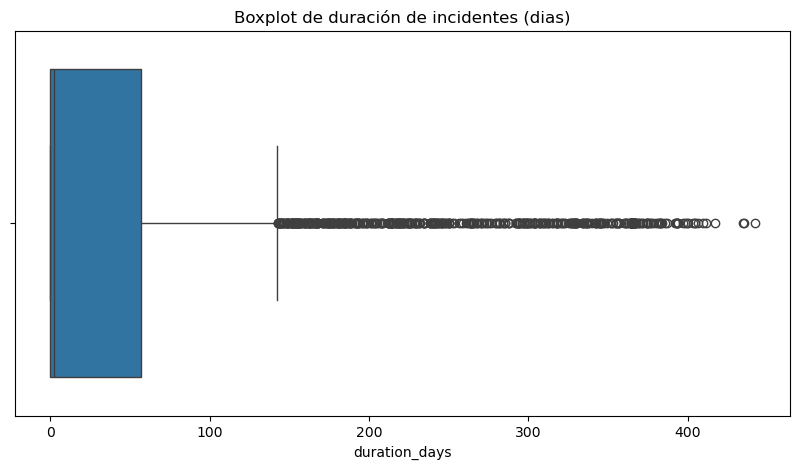

In [40]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_aux1['duration_days'])
plt.title('Boxplot de duración de incidentes (dias)')
plt.show()

Q1 (25%) = 0.0208 días

Q2 (50%) = 2.4159 días

Q3 (75%) = 57 días

una distribución con una cola extremadamente pesada y un 75% todavía relativamente bajo frente a la cola extrema

IQR=Q3−Q1=57−0.02≈56.98

big inf:
Q1−1.5⋅IQR≈0

big sup:
Q3+1.5⋅IQR=57+1.5x56.98=57+85x47=142.47

caja: 0.02 - 57 días

caja MUY grande en escala interna

mediana: 2.41 días

Outliers >142 dias

Zona típica (bulk real):

0 a 2–3 días (muchísima concentración)

mediana muy baja

Zona intermedia:

3 a 57 días (dentro del 50% central)

acá está la “variabilidad real del sistema”

Cola extrema (outliers):

mayor a 142 dias

# **Punto 2**

**Applicación de técnicas de visualización:**


*   Utilizar gráficos y técnicas de visualización aprendidos para ilustrar las principales características del dataset.
*   Emplear el gráfico correcto en función del tipo de variable y del análisis que se está realizando.
* Interpretar los resultados obtenidos a partir de las visualizaciones.



Muestro algunos gráficos de las variables que tienen que ver con datos personales de sospechosos y víctimas

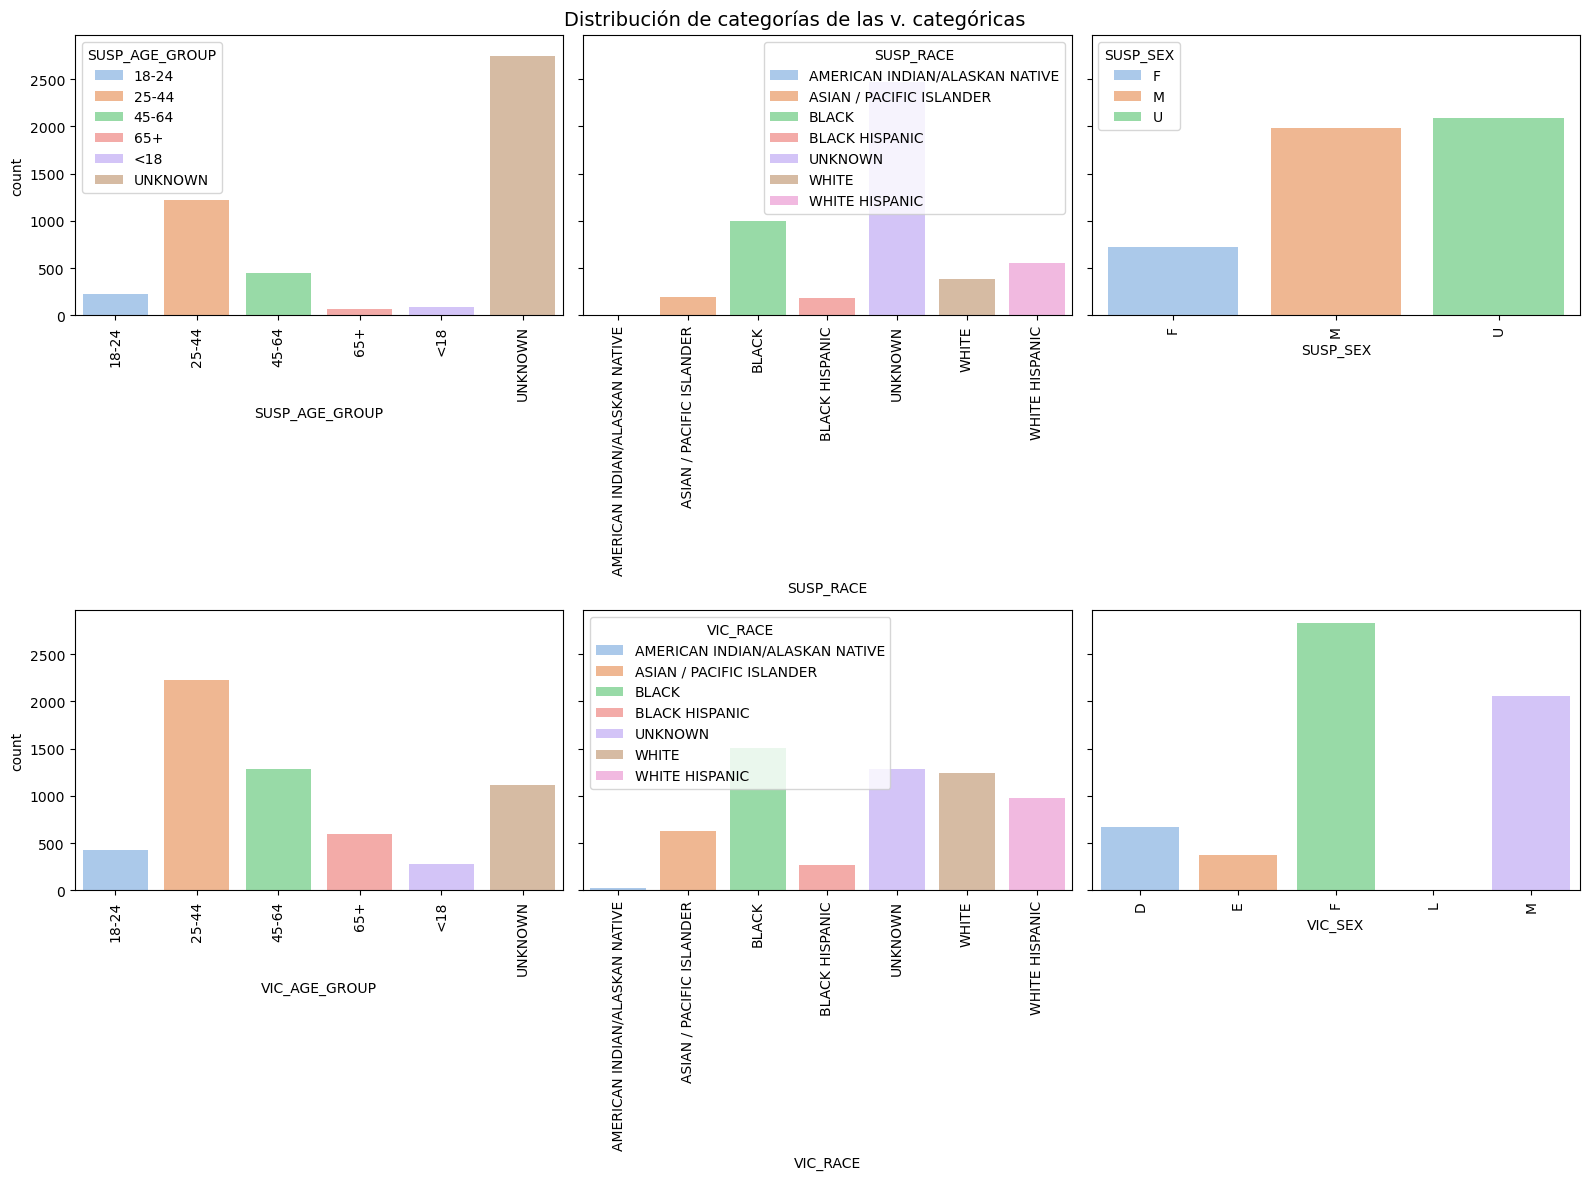

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12), sharey=True)
axes = axes.flatten()

for i, col in enumerate(['SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX', 'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX']):
    sns.countplot(x=col, data=df, hue=col, palette='pastel', ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)

plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

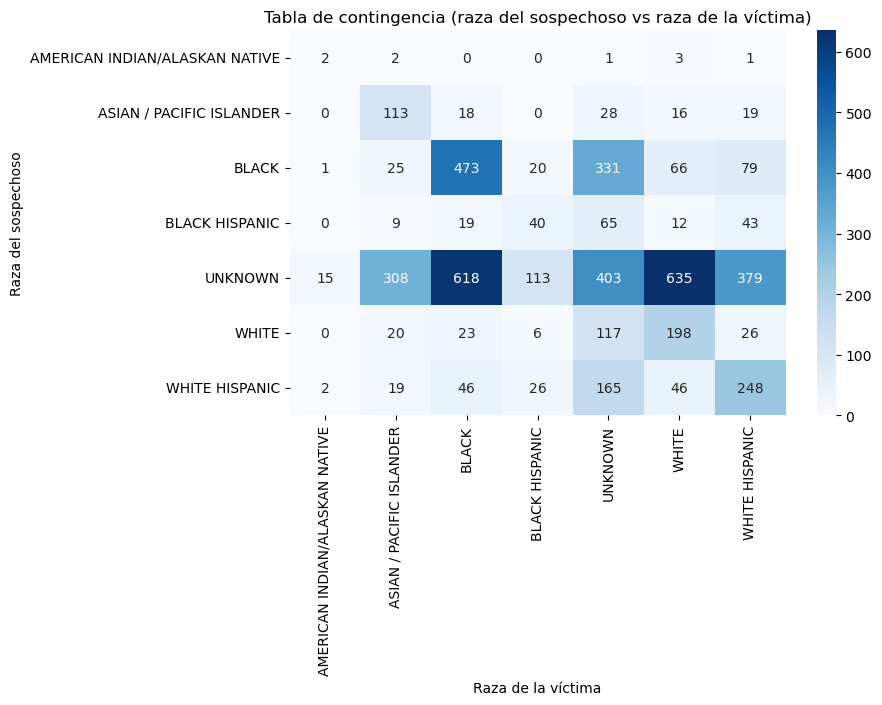

In [42]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['SUSP_RACE'], df['VIC_RACE'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (raza del sospechoso vs raza de la víctima)')
plt.xlabel('Raza de la víctima')
plt.ylabel('Raza del sospechoso')
plt.show()

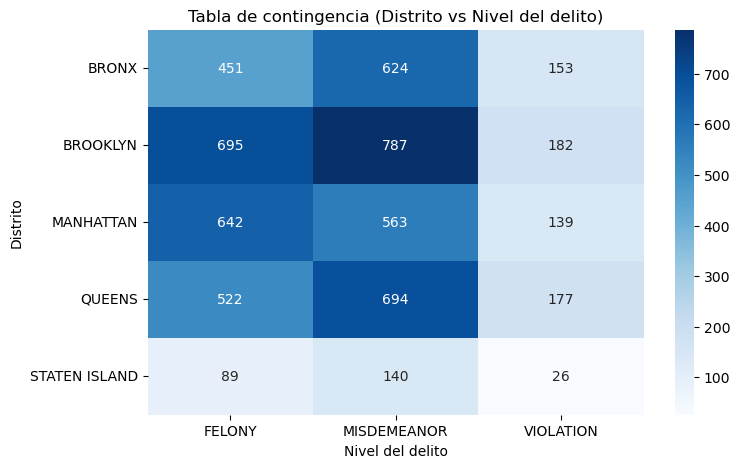

In [43]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['BORO_NM'], df['LAW_CAT_CD'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (Distrito vs Nivel del delito)')
plt.xlabel('Nivel del delito')
plt.ylabel('Distrito')
plt.show()

**Vamos a ver si hay relación entre algunas columnas**



In [44]:
# Funcion para calcular Cramér's V entre dos variables categóricas x e y
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


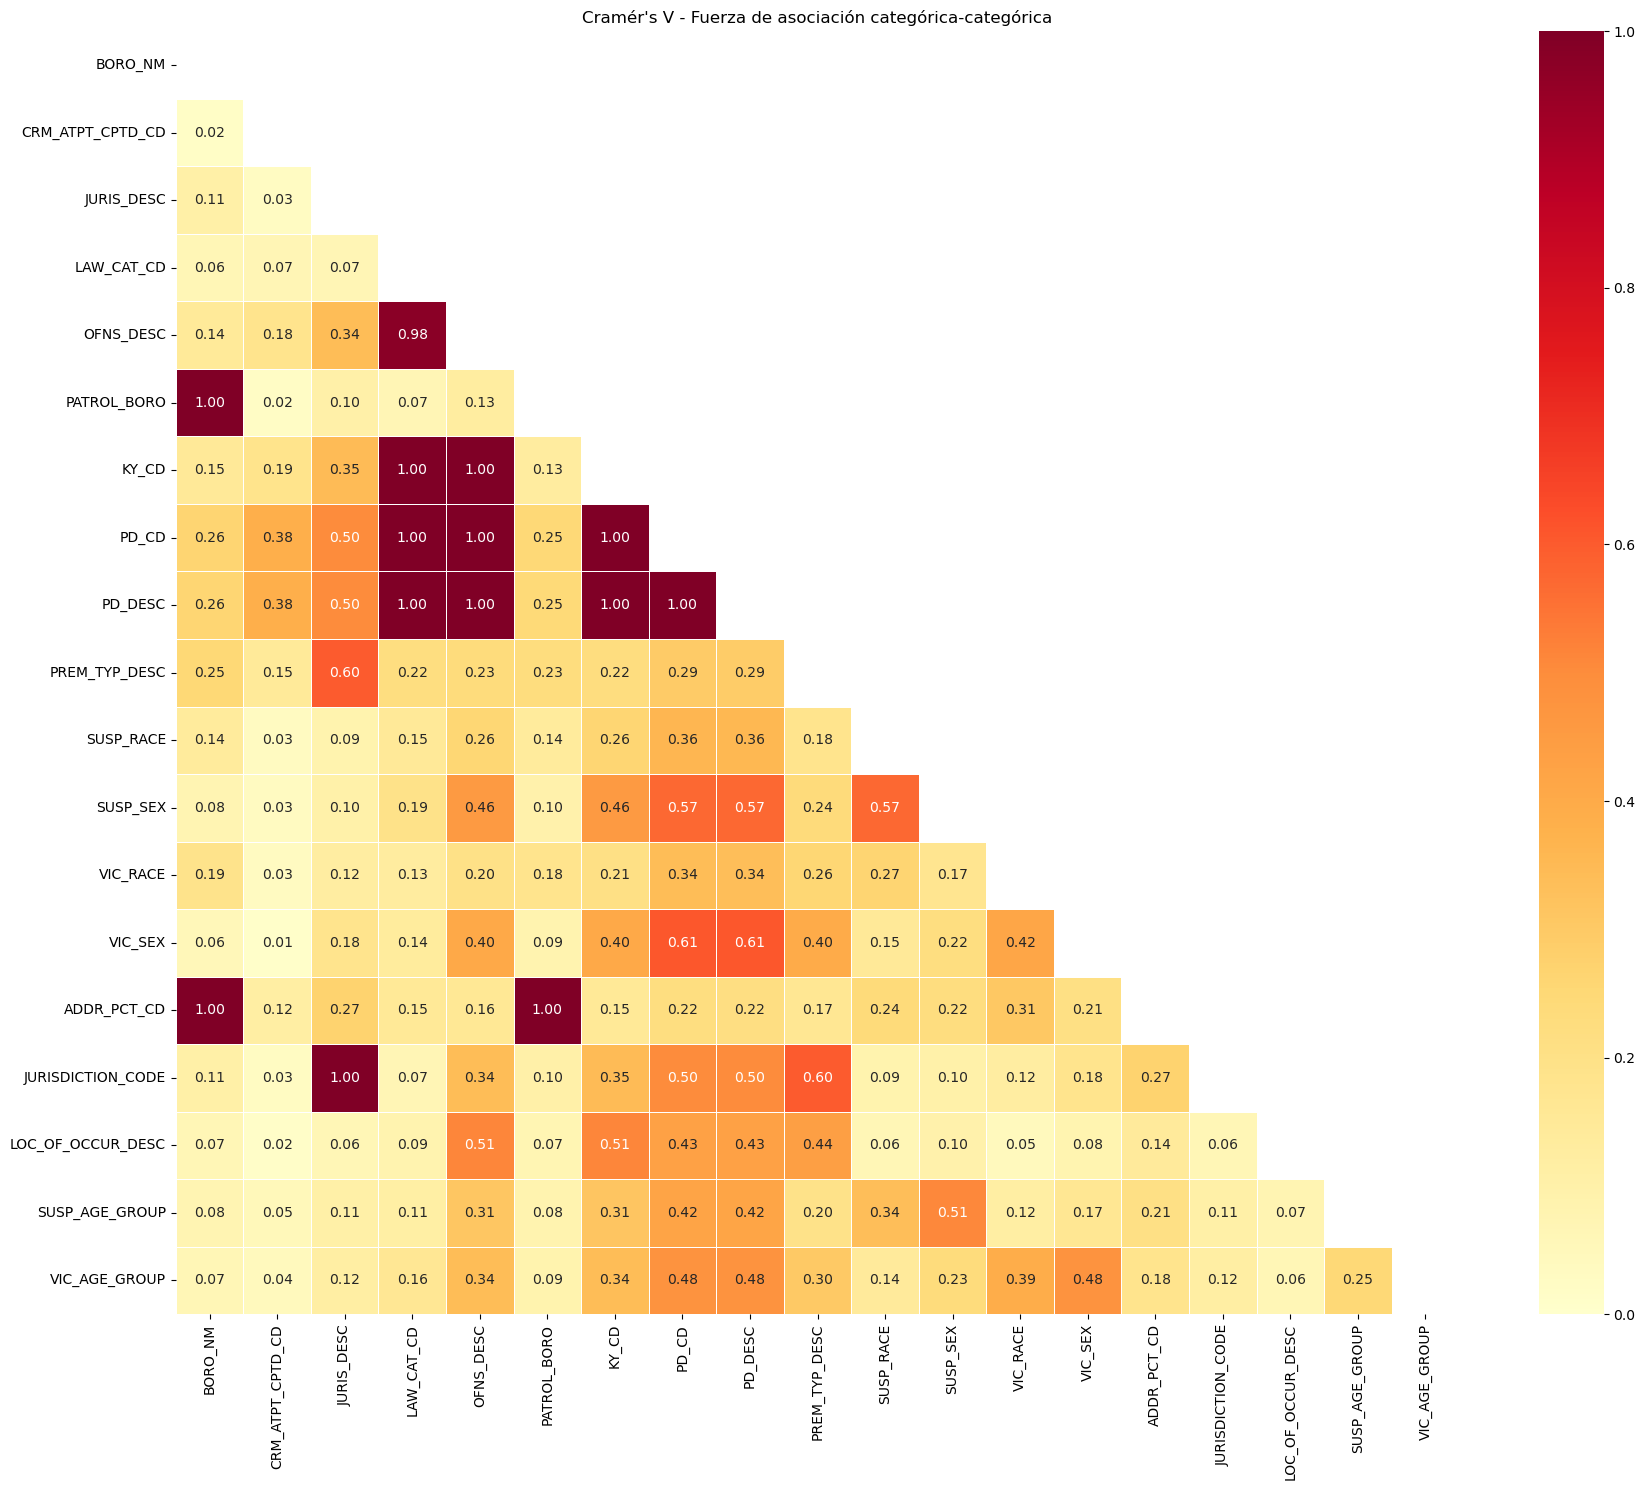

Top 25 asociaciones:
OFNS_DESC          KY_CD                1.000000
PD_DESC            PD_CD                1.000000
JURISDICTION_CODE  JURIS_DESC           1.000000
ADDR_PCT_CD        PATROL_BORO          1.000000
KY_CD              PD_CD                1.000000
LAW_CAT_CD         PD_CD                1.000000
KY_CD              OFNS_DESC            1.000000
PD_CD              LAW_CAT_CD           1.000000
JURIS_DESC         JURISDICTION_CODE    1.000000
PD_CD              OFNS_DESC            1.000000
                   KY_CD                1.000000
                   PD_DESC              1.000000
OFNS_DESC          PD_CD                1.000000
PATROL_BORO        ADDR_PCT_CD          1.000000
BORO_NM            ADDR_PCT_CD          0.999656
ADDR_PCT_CD        BORO_NM              0.999656
BORO_NM            PATROL_BORO          0.999653
PATROL_BORO        BORO_NM              0.999653
KY_CD              LAW_CAT_CD           0.999648
LAW_CAT_CD         KY_CD                0.999648

In [45]:
cat_cols = [
    c for c in delito_cat_nom
    if (
        df[c].nunique(dropna=True) > 1
        and
        df[c].isna().mean() < 0.50
    )
]

# Matriz de asociación
v_mat = pd.DataFrame(
    index=cat_cols,
    columns=cat_cols,
    dtype=float
)

for c1 in cat_cols:
    for c2 in cat_cols:

        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
            continue

        mask = df[c1].notna() & df[c2].notna()

        if mask.sum() == 0:
            v_mat.loc[c1, c2] = np.nan
            continue

        v_mat.loc[c1, c2] = cramers_v(
            df.loc[mask, c1],
            df.loc[mask, c2]
        )


# Máscara para mostrar solo la mitad inferior
mask = np.triu(np.ones_like(v_mat, dtype=bool))

# Heatmap
plt.figure(figsize=(18, 15))

sns.heatmap(
    v_mat.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    mask=mask
)

plt.title("Cramér's V - Fuerza de asociación categórica-categórica")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Top asociaciones más fuertes
corrs = (
    v_mat.where(~np.eye(v_mat.shape[0], dtype=bool))
         .stack()
         .sort_values(ascending=False)
)

print("Top 25 asociaciones:")
print(corrs.head(25))

1.  Asociaciones casi perfectas (redundancia)

| Variable 1 | Variable 2        | Cramér's V |
| ---------- | ----------------- | ---------- |
| OFNS_DESC  | PD_CD             | 1.00       |
| OFNS_DESC  | KY_CD             | 1.00       |
| JURIS_DESC | JURISDICTION_CODE | 1.00       |
| PD_CD      | PD_DESC           | 1.00       |
| PD_CD      | KY_CD             | 1.00       |
| LAW_CAT_CD | PD_CD             | 1.00       |
| LAW_CAT_CD | KY_CD             | 0.9996     |

Correspondencia 1 a 1

2.  Asociaciones geográficas

| Variable 1  | Variable 2  | Cramér's V |
| ----------- | ----------- | ---------- |
| ADDR_PCT_CD | BORO_NM     | 0.9997     |
| ADDR_PCT_CD | PATROL_BORO | 1.00       |
| BORO_NM     | PATROL_BORO | 0.9997     |

Precinto corresponde a un borough y a una zona de patrullaje determinada

3. Asociaciones interesantes

| Variable 1    | Variable 2 | Cramér's V |
| ------------- | ---------- | ---------- |
| VIC_SEX       | PD_CD      | 0.61       |
| VIC_SEX       | PD_DESC    | 0.61       |
| PREM_TYP_DESC | JURIS_DESC | 0.60       |
| SUSP_SEX      | PD_CD      | 0.57       |
| SUSP_SEX      | PD_DESC    | 0.57       |

son interesantes porque no son equivalencias directas.

Por ejemplo:
Algunos tipos de delito pueden ocurrir más frecuentemente sobre víctimas de determinado sexo.
Algunos tipos de establecimiento (PREM_TYP_DESC) pueden estar asociados a ciertas jurisdicciones.


entonces variables redundantes:


PD_CD
PD_DESC
KY_CD
OFNS_DESC

dejaría  para el procesamiento LAW_CAT_CD


y


JURISDICTION_CODE
JURIS_DESC

dejaría JURISDICTION_CODE


y

ADDR_PCT_CD
BORO_NM
PATROL_BORO

y dejaria para el procesamiento ADDR_PCT_CD

In [46]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")

    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)

    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})

    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [47]:
print_categorias(df,'OFNS_DESC')

Cantidad de categorías que tiene la variable 'OFNS_DESC': 39

Nombres de categorías presentes en la variable 'OFNS_DESC': ['HARRASSMENT 2', 'PETIT LARCENY', 'GRAND LARCENY', 'ROBBERY', 'OFFENSES AGAINST THE PERSON', ..., 'OFFENSES AGAINST PUBLIC SAFETY', 'INTOXICATED & IMPAIRED DRIVING', 'OFFENSES RELATED TO CHILDREN', 'PROSTITUTION & RELATED OFFENSES', 'ANTICIPATORY OFFENSES']
Length: 39
Categories (39, object): ['ADMINISTRATIVE CODE', 'ANTICIPATORY OFFENSES', 'ARSON', 'ASSAULT 3 & RELATED OFFENSES', ..., 'SEX CRIMES', 'THEFT-FRAUD', 'UNAUTHORIZED USE OF A VEHICLE', 'VEHICLE AND TRAFFIC LAWS']

Frecuencias de cada categoría en la variable 'OFNS_DESC':
                                  Frecuencia absoluta  Frecuencia relativa (%)
OFNS_DESC                                                                     
PETIT LARCENY                                    1551                    26.12
GRAND LARCENY                                    1230                    20.71
HARRASSMENT 2          

<Axes: xlabel='OFNS_DESC'>

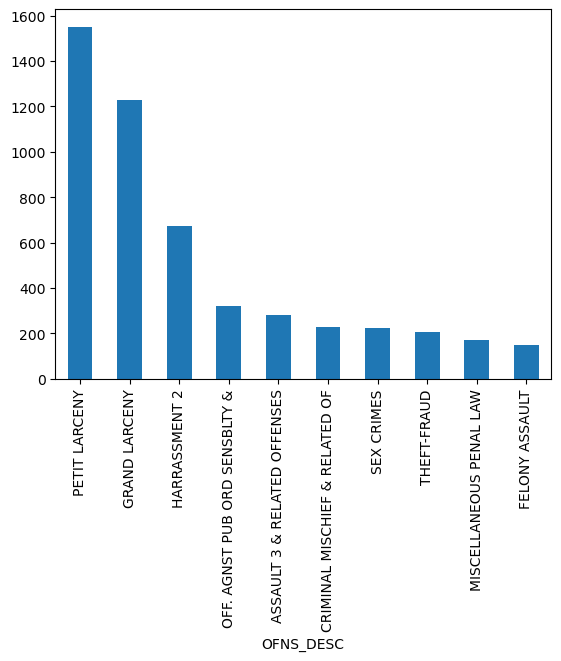

In [48]:
df['OFNS_DESC'].value_counts().head(10).plot(kind='bar')

In [49]:
print_categorias(df,'LAW_CAT_CD')

Cantidad de categorías que tiene la variable 'LAW_CAT_CD': 3

Nombres de categorías presentes en la variable 'LAW_CAT_CD': ['VIOLATION', 'MISDEMEANOR', 'FELONY']
Categories (3, object): ['FELONY', 'MISDEMEANOR', 'VIOLATION']

Frecuencias de cada categoría en la variable 'LAW_CAT_CD':
             Frecuencia absoluta  Frecuencia relativa (%)
LAW_CAT_CD                                               
MISDEMEANOR                 2862                    48.19
FELONY                      2400                    40.41
VIOLATION                    677                    11.40



<Axes: xlabel='LAW_CAT_CD'>

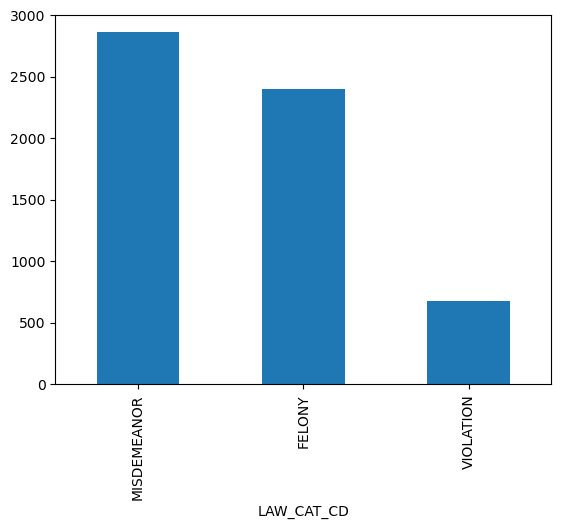

In [50]:
df['LAW_CAT_CD'].value_counts().plot(kind='bar')

In [51]:
print_categorias(df,'BORO_NM')

Cantidad de categorías que tiene la variable 'BORO_NM': 5

Nombres de categorías presentes en la variable 'BORO_NM': ['BROOKLYN', 'QUEENS', 'STATEN ISLAND', NaN, 'MANHATTAN', 'BRONX']
Categories (5, object): ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']

Frecuencias de cada categoría en la variable 'BORO_NM':
               Frecuencia absoluta  Frecuencia relativa (%)
BORO_NM                                                    
BROOKLYN                      1664                    28.28
QUEENS                        1393                    23.67
MANHATTAN                     1344                    22.84
BRONX                         1228                    20.87
STATEN ISLAND                  255                     4.33



<Axes: xlabel='BORO_NM'>

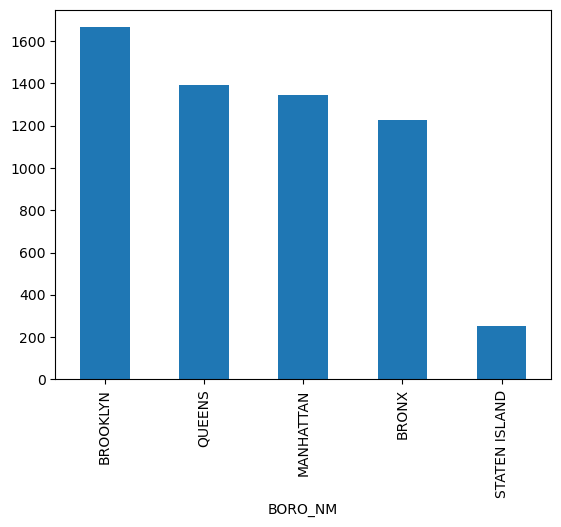

In [52]:
df['BORO_NM'].value_counts().plot(kind='bar')

In [53]:
# genero un df para graficar...despues procesaremos
df_aux=df.copy()
df_aux['CMPLNT_FR_DT'] = pd.to_datetime(df_aux['CMPLNT_FR_DT'])
df_aux['anio'] = df_aux['CMPLNT_FR_DT'].dt.year
df_aux['mes'] = df_aux['CMPLNT_FR_DT'].dt.month
df_aux['dia_semana'] = df_aux['CMPLNT_FR_DT'].dt.dayofweek



In [54]:
print_categorias(df_aux,'mes')

Cantidad de categorías que tiene la variable 'mes': 12

Nombres de categorías presentes en la variable 'mes': [ 1 12 11 10  7  9  8  6  4  2  3  5]

Frecuencias de cada categoría en la variable 'mes':
     Frecuencia absoluta  Frecuencia relativa (%)
mes                                              
12                  2944                    49.57
11                   841                    14.16
10                   498                     8.39
1                    306                     5.15
9                    302                     5.09
8                    237                     3.99
7                    179                     3.01
6                    143                     2.41
2                    140                     2.36
3                    140                     2.36
5                    117                     1.97
4                     92                     1.55



<Axes: xlabel='mes', ylabel='Count'>

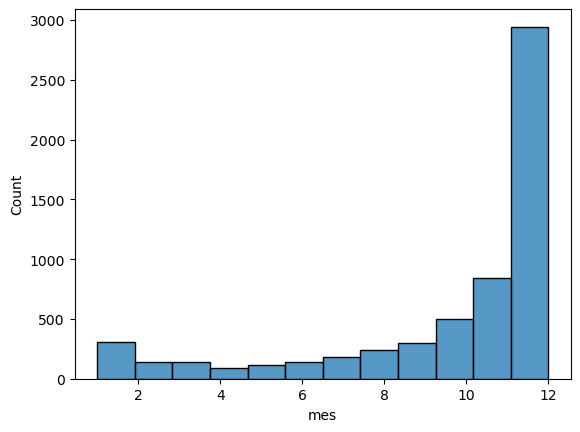

In [55]:
sns.histplot(df_aux['mes'], bins=12)

In [56]:
df_aux['hora'] = pd.to_datetime(
    df_aux['CMPLNT_FR_TM'],
    format='%H:%M:%S'
).dt.hour

In [57]:
print_categorias(df_aux,'hora')

Cantidad de categorías que tiene la variable 'hora': 24

Nombres de categorías presentes en la variable 'hora': [13 10 21 20 19 11 15  3 12 18  9  1 14  0 16  4  8 22 17  7  5  6 23  2]

Frecuencias de cada categoría en la variable 'hora':
      Frecuencia absoluta  Frecuencia relativa (%)
hora                                              
12                    640                    10.78
0                     554                     9.33
15                    416                     7.00
10                    354                     5.96
9                     345                     5.81
14                    333                     5.61
8                     329                     5.54
11                    309                     5.20
13                    305                     5.14
16                    290                     4.88
17                    290                     4.88
18                    275                     4.63
19                    223                     

<Axes: xlabel='hora', ylabel='Count'>

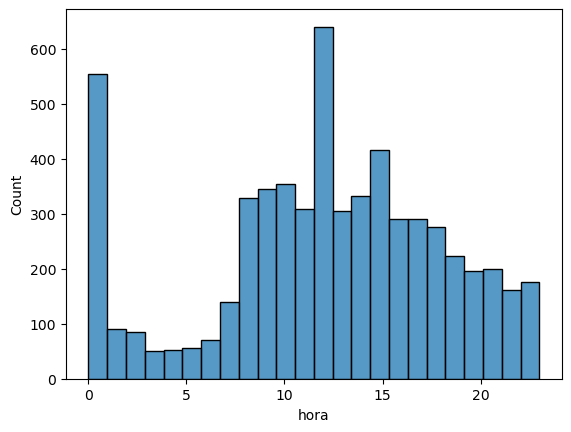

In [58]:
sns.histplot(df_aux['hora'], bins=24)

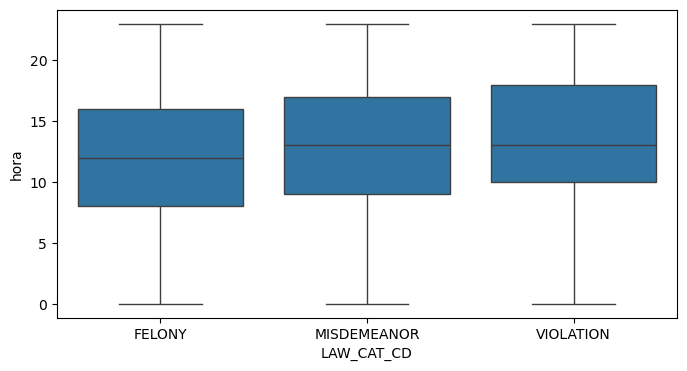

In [59]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_aux,
    x='LAW_CAT_CD',
    y='hora'
)

plt.show()

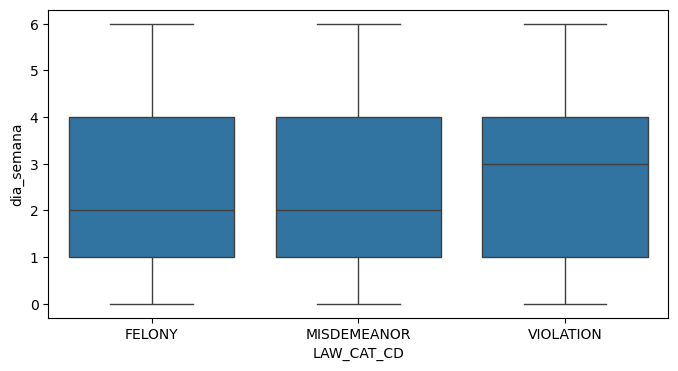

In [60]:

plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_aux,
    x='LAW_CAT_CD',
    y='dia_semana'
)

plt.show()

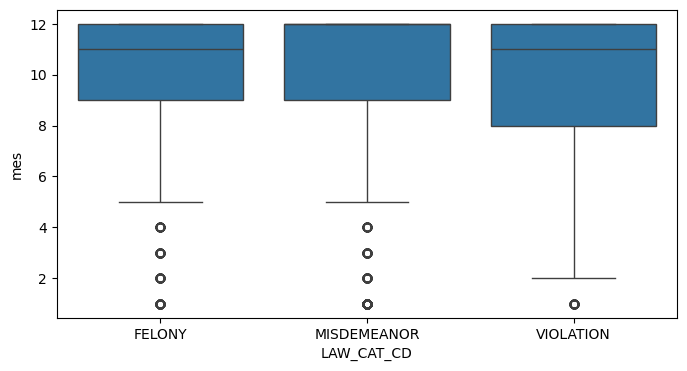

In [61]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_aux,
    x='LAW_CAT_CD',
    y='mes'
)

plt.show()

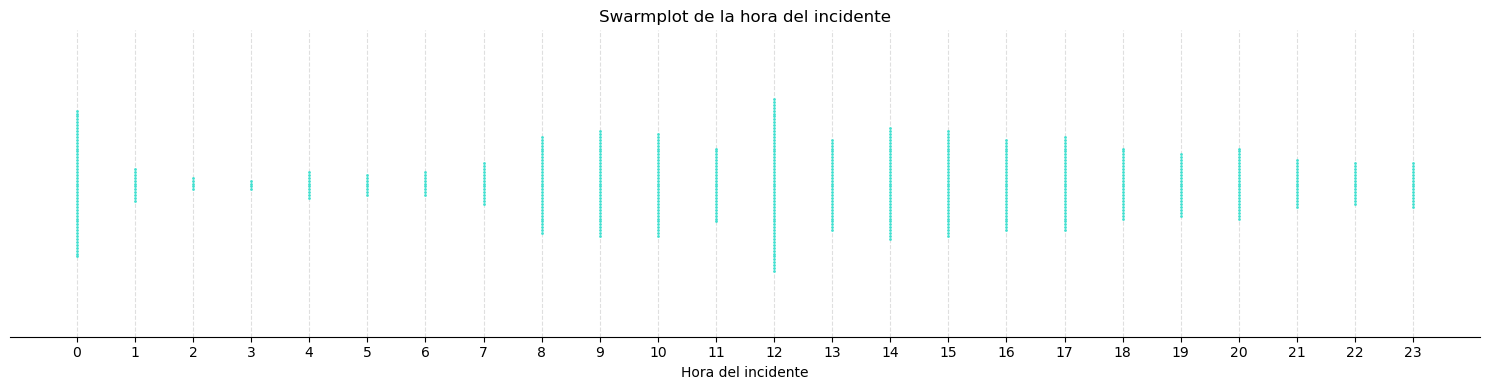

In [62]:
df_sample = df_aux.sample(
    n=min(600, len(df_aux)),
    random_state=42
)

plt.figure(figsize=(15, 4))

sns.swarmplot(
    x=df_sample['hora'],
    color='turquoise',
    size=2
)

ax = plt.gca()

ax.set_xticks(np.arange(0, 24, 1))
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("Hora del incidente")

sns.despine(left=True)

plt.title("Swarmplot de la hora del incidente")
plt.tight_layout()
plt.show()

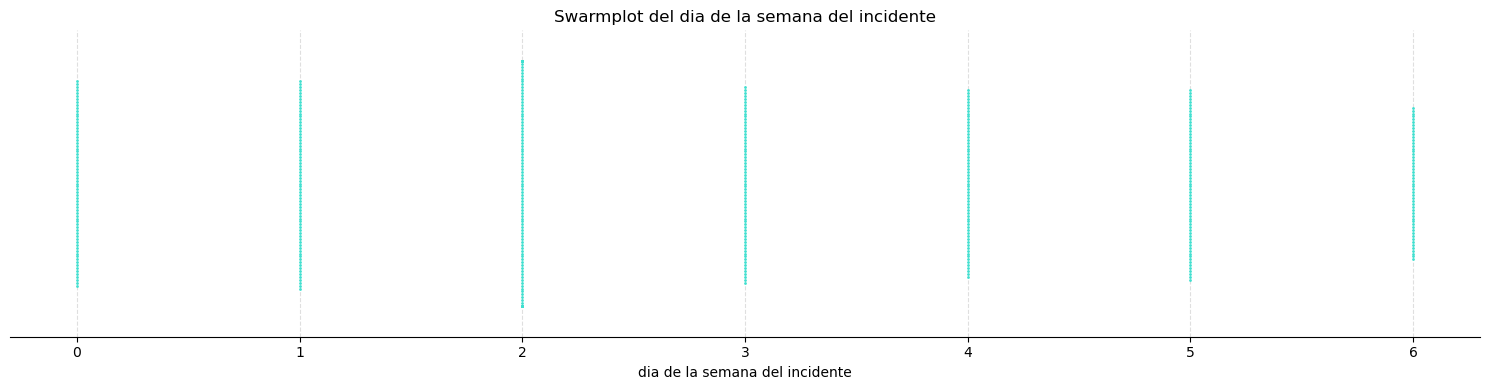

In [63]:
df_sample = df_aux.sample(
    n=min(500, len(df_aux)),
    random_state=42
)

plt.figure(figsize=(15, 4))

sns.swarmplot(
    x=df_sample['dia_semana'],
    color='turquoise',
    size=2
)

ax = plt.gca()

ax.set_xticks(np.arange(0, 7, 1))
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("dia de la semana del incidente")

sns.despine(left=True)


plt.title("Swarmplot del dia de la semana del incidente")
plt.tight_layout()
plt.show()

# **Punto 3**

**Plantear un posible problema de ML supervisado a partir de los datos elegidos**

*   Describir el problema de clasificación o regresión.
*   Definir la variable target.


El problema de ML supervisado será de clasificacion y el target será el atributo categorico: LAW_CAT_CD (indica categoría del nivel del delito).

#**Punto 4**

**Preprocesamiento y limpieza del dataset**

* Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o relevantes.
* Realizar el split del dataset.
* Identificar y tratar los valores faltantes en el dataset.
* Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.
* Escalar / normalizar los features.

recordatorio:
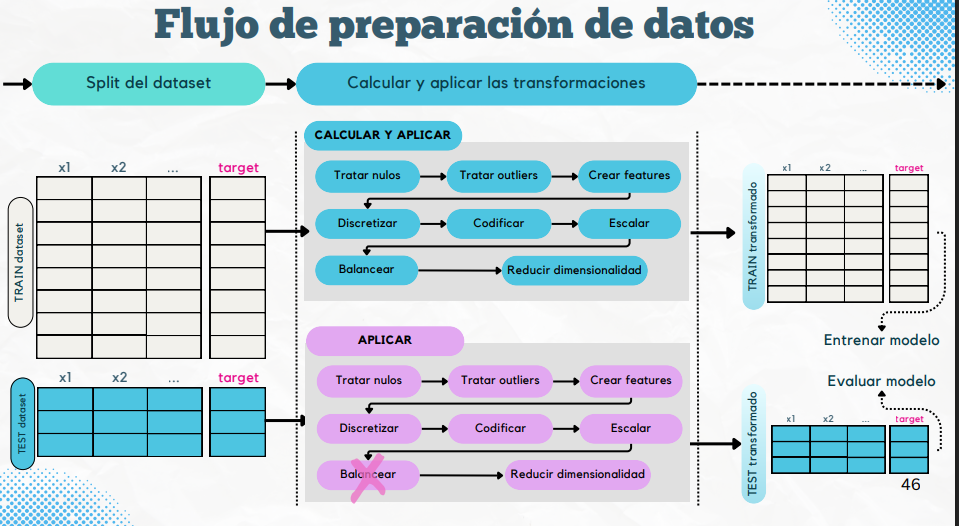

In [64]:
df_aux3=df.copy()

otro repaso:
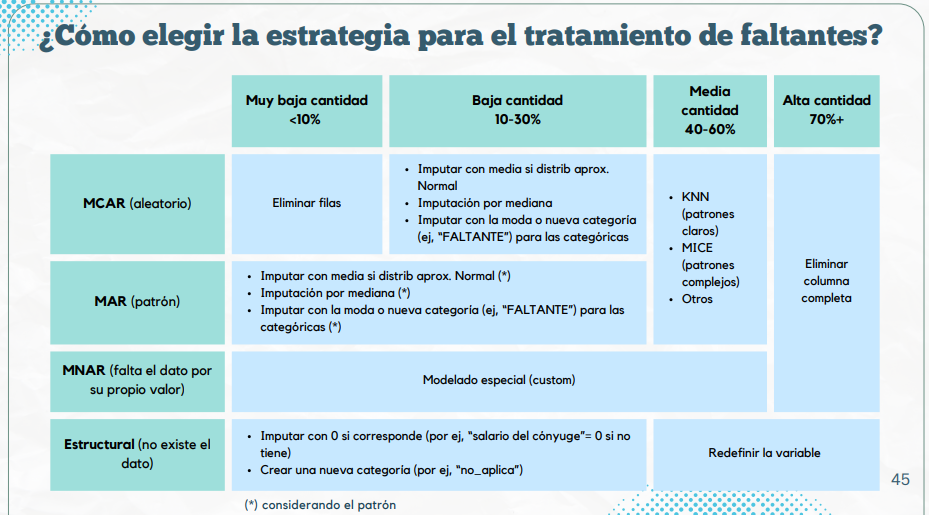

redefino algunas features o elimino con >90 por ciento nulos que son estructurales y elimino id CMPLNT_NUM

Debido a que estas variables presentaban más del 90% de valores nulos, se reemplazaron por indicadores binarios de presencia (IN_PARK, IN_TRANSIT, IN_HOUSING), conservando la información relevante y evitando trabajar con columnas de alta cardinalidad y escasa completitud.

In [65]:

df_aux3['IN_PARK'] = df_aux3['PARKS_NM'].notna().astype(int)

df_aux3['IN_TRANSIT'] = (
    df_aux3['STATION_NAME'].notna() |
    df_aux3['TRANSIT_DISTRICT'].notna()
).astype(int)

df_aux3['IN_HOUSING'] = (
    df_aux3['HOUSING_PSA'].notna() |
    df_aux3['HADEVELOPT'].notna()
).astype(int)

df_aux3 = df_aux3.drop(columns=["CMPLNT_NUM","HOUSING_PSA","TRANSIT_DISTRICT","PARKS_NM","HADEVELOPT","STATION_NAME"])


In [66]:
df_aux3


,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,JURISDICTION_CODE,JURIS_DESC,KY_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PATROL_BORO,PD_CD,PD_DESC,PREM_TYP_DESC,RPT_DT,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,IN_PARK,IN_TRANSIT,IN_HOUSING
69,60,BROOKLYN,01/01/2025,13:40:00,01/01/2026,13:45:00,COMPLETED,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",GROCERY/BODEGA,01/01/2026,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,989419,149229,"40,576284","-73,981392","(40.576284, -73.981392)",POINT (-73.981392 40.576284),0,0,0
70,101,QUEENS,12/30/2025,10:34:00,12/30/2025,21:00:00,COMPLETED,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,PATROL BORO QUEENS SOUTH,352.0,"LARCENY,PETIT FROM BUILDING,UNATTENDED, PACKAG...",RESIDENCE - APT. HOUSE,01/03/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,1051811,156239,"40,59527","-73,756726","(40.59527, -73.756726)",POINT (-73.756726 40.59527),0,0,0
95,63,BROOKLYN,12/31/2025,21:00:00,12/31/2025,21:30:00,COMPLETED,0,N.Y. POLICE DEPT,578,VIOLATION,FRONT OF,HARRASSMENT 2,PATROL BORO BKLYN SOUTH,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE-HOUSE,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1007120,166200,"40,622837","-73,917614","(40.622837, -73.917614)",POINT (-73.917614 40.622837),0,0,0
99,60,BROOKLYN,11/20/2025,20:00:00,11/20/2025,21:00:00,COMPLETED,0,N.Y. POLICE DEPT,109,FELONY,INSIDE,GRAND LARCENY,PATROL BORO BKLYN SOUTH,412.0,"LARCENY,GRAND FROM RESIDENCE, UNATTENDED",RESIDENCE - APT. HOUSE,02/11/2026,45-64,BLACK,F,45-64,BLACK,M,988814,149158,"40,576087","-73,983569","(40.576087, -73.983569)",POINT (-73.983569 40.576087),0,0,0
108,60,BROOKLYN,12/28/2025,19:09:00,12/28/2025,19:10:00,COMPLETED,0,N.Y. POLICE DEPT,105,FELONY,INSIDE,ROBBERY,PATROL BORO BKLYN SOUTH,399.0,"ROBBERY,COMMERCIAL UNCLASSIFIED",FAST FOOD,01/02/2026,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,985092,148865,"40,575285","-73,996969","(40.575285, -73.996969)",POINT (-73.996969 40.575285),0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,BRONX,12/31/2025,12:19:00,12/31/2025,12:25:00,COMPLETED,0,N.Y. POLICE DEPT,109,FELONY,FRONT OF,GRAND LARCENY,PATROL BORO BRONX,457.0,"LARCENY,GRAND OF VEHICULAR/MOTORCYCLE ACCESSORIES",STREET,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1024351,260917,"40,88275","-73,85498","(40.88275, -73.85498)",POINT (-73.85498 40.88275),0,0,0
133020,45,BRONX,12/20/2025,08:00:00,01/24/2026,09:00:00,COMPLETED,0,N.Y. POLICE DEPT,578,VIOLATION,INSIDE,HARRASSMENT 2,PATROL BORO BRONX,638.0,"HARASSMENT,SUBD 3,4,5",RESIDENCE - APT. HOUSE,03/14/2026,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,1032451,257889,"40,874398","-73,825707","(40.874398, -73.825707)",POINT (-73.825707 40.874398),0,0,0
133036,47,BRONX,12/30/2025,13:00:00,01/06/2026,15:00:00,COMPLETED,0,N.Y. POLICE DEPT,341,MISDEMEANOR,INSIDE,PETIT LARCENY,PATROL BORO BRONX,349.0,"LARCENY,PETIT OF LICENSE PLATE",STORAGE FACILITY,01/06/2026,NaN,NaN,NaN,65+,WHITE,M,1028591,258644,"40,87649","-73,839661","(40.87649, -73.839661)",POINT (-73.839661 40.87649),0,0,0
133089,52,BRONX,12/01/2025,22:35:00,NaN,NaN,COMPLETED,0,N.Y. POLICE DEPT,361,MISDEMEANOR,INSIDE,OFF. AGNST PUB ORD SENSBLTY &,PATROL BORO BRONX,639.0,AGGRAVATED HARASSMENT 2,RESIDENCE - APT. HOUSE,02/04/2026,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,1018488,258415,"40,875908","-73,876194","(40.875908, -73.876194)",POINT (-73.876194 40.875908),0,0,0


saco redundantes obtenidos de antes

In [67]:
df_aux3 = df_aux3.drop(columns=[
    'PD_CD',
    'KY_CD',
    'PD_DESC',
    'OFNS_DESC',
    'JURIS_DESC',
    'BORO_NM',
    'PATROL_BORO'
])

Saco también las columnas con baja correlación con la variable target:


*   0.09 'LOC_OF_OCCUR_DESC'
*   0.07 'JURISDICTION_CODE'
*   0.07 'PATROL_BORO' (ya fue eliminada en el paso anterior)

Se entiende que estas variables no aportan a la predicción que se busca



In [68]:
df_aux3 = df_aux3.drop(columns=[
    'LOC_OF_OCCUR_DESC',
    'JURISDICTION_CODE'
])

In [69]:
df_aux3

,ADDR_PCT_CD,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,RPT_DT,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,IN_PARK,IN_TRANSIT,IN_HOUSING
69,60,01/01/2025,13:40:00,01/01/2026,13:45:00,COMPLETED,VIOLATION,GROCERY/BODEGA,01/01/2026,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,989419,149229,"40,576284","-73,981392","(40.576284, -73.981392)",POINT (-73.981392 40.576284),0,0,0
70,101,12/30/2025,10:34:00,12/30/2025,21:00:00,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,01/03/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,1051811,156239,"40,59527","-73,756726","(40.59527, -73.756726)",POINT (-73.756726 40.59527),0,0,0
95,63,12/31/2025,21:00:00,12/31/2025,21:30:00,COMPLETED,VIOLATION,RESIDENCE-HOUSE,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1007120,166200,"40,622837","-73,917614","(40.622837, -73.917614)",POINT (-73.917614 40.622837),0,0,0
99,60,11/20/2025,20:00:00,11/20/2025,21:00:00,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,02/11/2026,45-64,BLACK,F,45-64,BLACK,M,988814,149158,"40,576087","-73,983569","(40.576087, -73.983569)",POINT (-73.983569 40.576087),0,0,0
108,60,12/28/2025,19:09:00,12/28/2025,19:10:00,COMPLETED,FELONY,FAST FOOD,01/02/2026,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,985092,148865,"40,575285","-73,996969","(40.575285, -73.996969)",POINT (-73.996969 40.575285),0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,12/31/2025,12:19:00,12/31/2025,12:25:00,COMPLETED,FELONY,STREET,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1024351,260917,"40,88275","-73,85498","(40.88275, -73.85498)",POINT (-73.85498 40.88275),0,0,0
133020,45,12/20/2025,08:00:00,01/24/2026,09:00:00,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,03/14/2026,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,1032451,257889,"40,874398","-73,825707","(40.874398, -73.825707)",POINT (-73.825707 40.874398),0,0,0
133036,47,12/30/2025,13:00:00,01/06/2026,15:00:00,COMPLETED,MISDEMEANOR,STORAGE FACILITY,01/06/2026,NaN,NaN,NaN,65+,WHITE,M,1028591,258644,"40,87649","-73,839661","(40.87649, -73.839661)",POINT (-73.839661 40.87649),0,0,0
133089,52,12/01/2025,22:35:00,NaN,NaN,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,02/04/2026,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,1018488,258415,"40,875908","-73,876194","(40.875908, -73.876194)",POINT (-73.876194 40.875908),0,0,0


Lo puedo hacer antes del split porque no uso ningun estadistico. Por eso no hay riesgo de data leakage.

In [70]:
validos = ["<18", "18-24", "25-44", "45-64", "65+"]
df_aux3['SUSP_AGE_GROUP'] = df_aux3['SUSP_AGE_GROUP'].astype(str)

df_aux3['SUSP_AGE_GROUP'] = df_aux3['SUSP_AGE_GROUP'].apply(
    lambda x: x if x in validos else "UNKNOWN"
)
df_aux3['SUSP_AGE_GROUP'] = df_aux3['SUSP_AGE_GROUP'].replace("nan", "UNKNOWN")

In [71]:
df_aux3['SUSP_AGE_GROUP'].value_counts()

SUSP_AGE_GROUP
UNKNOWN    3884
25-44      1226
45-64       451
18-24       222
<18          88
65+          68
Name: count, dtype: int64

In [72]:
validos = ["<18", "18-24", "25-44", "45-64", "65+"]
df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].astype(str)

df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].apply(
    lambda x: x if x in validos else "UNKNOWN"
)
df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].replace("nan", "UNKNOWN")

In [73]:
df_aux3.VIC_AGE_GROUP.value_counts()

VIC_AGE_GROUP
25-44      2228
45-64      1284
UNKNOWN    1119
65+         594
18-24       433
<18         281
Name: count, dtype: int64

In [74]:
validos = ["<18", "18-24", "25-44", "45-64", "65+"]
df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].astype(str)

df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].apply(
    lambda x: x if x in validos else "UNKNOWN"
)
df_aux3['VIC_AGE_GROUP'] = df_aux3['VIC_AGE_GROUP'].replace("nan", "UNKNOWN")

In [75]:
df_aux3['VIC_AGE_GROUP'].value_counts()

VIC_AGE_GROUP
25-44      2228
45-64      1284
UNKNOWN    1119
65+         594
18-24       433
<18         281
Name: count, dtype: int64

In [76]:

validos = ["BLACK", "WHITE HISPANIC","WHITE", "ASIAN / PACIFIC ISLANDER", "BLACK HISPANIC", "AMERICAN INDIAN/ALASKAN NATIVE"]
df_aux3['VIC_RACE'] = df_aux3['VIC_RACE'].astype(str)

df_aux3['VIC_RACE'] = df_aux3['VIC_RACE'].apply(
    lambda x: x if x in validos else "UNKNOWN"
)
df_aux3['VIC_RACE'] = df_aux3['VIC_RACE'].replace("nan", "UNKNOWN")

In [77]:
df_aux3.VIC_RACE.value_counts()

VIC_RACE
BLACK                             1508
UNKNOWN                           1294
WHITE                             1238
WHITE HISPANIC                     979
ASIAN / PACIFIC ISLANDER           626
BLACK HISPANIC                     267
AMERICAN INDIAN/ALASKAN NATIVE      27
Name: count, dtype: int64

In [78]:

validos = ["BLACK", "WHITE HISPANIC","WHITE", "ASIAN / PACIFIC ISLANDER", "BLACK HISPANIC", "AMERICAN INDIAN/ALASKAN NATIVE"]
df_aux3['SUSP_RACE'] = df_aux3['SUSP_RACE'].astype(str)

df_aux3['SUSP_RACE'] = df_aux3['SUSP_RACE'].apply(
    lambda x: x if x in validos else "UNKNOWN"
)
df_aux3['SUSP_RACE'] = df_aux3['SUSP_RACE'].replace("nan", "UNKNOWN")

In [79]:
df_aux3['SUSP_RACE'].value_counts()

SUSP_RACE
UNKNOWN                           3611
BLACK                              995
WHITE HISPANIC                     552
WHITE                              390
ASIAN / PACIFIC ISLANDER           194
BLACK HISPANIC                     188
AMERICAN INDIAN/ALASKAN NATIVE       9
Name: count, dtype: int64

In [80]:
#df_aux3['LOC_OF_OCCUR_DESC'] = (
#    df_aux3['LOC_OF_OCCUR_DESC']
#    .cat.add_categories(['UNKNOWN'])
#    .fillna('UNKNOWN')
#)

In [81]:
#df_aux3['LOC_OF_OCCUR_DESC'].value_counts()

In [82]:
validos = ["M", "U", "F"]
df_aux3['SUSP_SEX'] = df_aux3['SUSP_SEX'].astype(str)

df_aux3['SUSP_SEX'] = df_aux3['SUSP_SEX'].apply(
    lambda x: x if x in validos else "U"
)
df_aux3['SUSP_SEX'] = df_aux3['SUSP_SEX'].replace("nan", "U")

In [83]:
df_aux3.SUSP_SEX.value_counts()

SUSP_SEX
U    3224
M    1987
F     728
Name: count, dtype: int64

In [84]:
df_aux3['PREM_TYP_DESC'] = (
    df_aux3['PREM_TYP_DESC']
    .cat.add_categories(['UNKNOWN'])
    .fillna('UNKNOWN')
)

In [85]:
df_aux3['PREM_TYP_DESC'].value_counts()

PREM_TYP_DESC
RESIDENCE - APT. HOUSE        2091
RESIDENCE-HOUSE                986
STREET                         904
RESIDENCE - PUBLIC HOUSING     320
CHAIN STORE                    218
                              ... 
CEMETERY                         1
FERRY/FERRY TERMINAL             1
LOAN COMPANY                     1
MOSQUE                           1
ABANDONED BUILDING               1
Name: count, Length: 72, dtype: int64

In [86]:
df_aux3

,ADDR_PCT_CD,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,RPT_DT,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column,IN_PARK,IN_TRANSIT,IN_HOUSING
69,60,01/01/2025,13:40:00,01/01/2026,13:45:00,COMPLETED,VIOLATION,GROCERY/BODEGA,01/01/2026,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,989419,149229,"40,576284","-73,981392","(40.576284, -73.981392)",POINT (-73.981392 40.576284),0,0,0
70,101,12/30/2025,10:34:00,12/30/2025,21:00:00,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,01/03/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,1051811,156239,"40,59527","-73,756726","(40.59527, -73.756726)",POINT (-73.756726 40.59527),0,0,0
95,63,12/31/2025,21:00:00,12/31/2025,21:30:00,COMPLETED,VIOLATION,RESIDENCE-HOUSE,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1007120,166200,"40,622837","-73,917614","(40.622837, -73.917614)",POINT (-73.917614 40.622837),0,0,0
99,60,11/20/2025,20:00:00,11/20/2025,21:00:00,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,02/11/2026,45-64,BLACK,F,45-64,BLACK,M,988814,149158,"40,576087","-73,983569","(40.576087, -73.983569)",POINT (-73.983569 40.576087),0,0,0
108,60,12/28/2025,19:09:00,12/28/2025,19:10:00,COMPLETED,FELONY,FAST FOOD,01/02/2026,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,985092,148865,"40,575285","-73,996969","(40.575285, -73.996969)",POINT (-73.996969 40.575285),0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,12/31/2025,12:19:00,12/31/2025,12:25:00,COMPLETED,FELONY,STREET,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,1024351,260917,"40,88275","-73,85498","(40.88275, -73.85498)",POINT (-73.85498 40.88275),0,0,0
133020,45,12/20/2025,08:00:00,01/24/2026,09:00:00,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,03/14/2026,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,1032451,257889,"40,874398","-73,825707","(40.874398, -73.825707)",POINT (-73.825707 40.874398),0,0,0
133036,47,12/30/2025,13:00:00,01/06/2026,15:00:00,COMPLETED,MISDEMEANOR,STORAGE FACILITY,01/06/2026,UNKNOWN,UNKNOWN,U,65+,WHITE,M,1028591,258644,"40,87649","-73,839661","(40.87649, -73.839661)",POINT (-73.839661 40.87649),0,0,0
133089,52,12/01/2025,22:35:00,NaN,NaN,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,02/04/2026,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,1018488,258415,"40,875908","-73,876194","(40.875908, -73.876194)",POINT (-73.876194 40.875908),0,0,0


borro las columnas geofraficas

In [87]:
df_aux3 = df_aux3.drop(columns=["Lat_Lon","New Georeferenced Column","X_COORD_CD","Y_COORD_CD","Latitude","Longitude"])

In [88]:
df_aux3

,ADDR_PCT_CD,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,RPT_DT,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,IN_PARK,IN_TRANSIT,IN_HOUSING
69,60,01/01/2025,13:40:00,01/01/2026,13:45:00,COMPLETED,VIOLATION,GROCERY/BODEGA,01/01/2026,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,0,0,0
70,101,12/30/2025,10:34:00,12/30/2025,21:00:00,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,01/03/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,0,0,0
95,63,12/31/2025,21:00:00,12/31/2025,21:30:00,COMPLETED,VIOLATION,RESIDENCE-HOUSE,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0
99,60,11/20/2025,20:00:00,11/20/2025,21:00:00,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,02/11/2026,45-64,BLACK,F,45-64,BLACK,M,0,0,0
108,60,12/28/2025,19:09:00,12/28/2025,19:10:00,COMPLETED,FELONY,FAST FOOD,01/02/2026,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,12/31/2025,12:19:00,12/31/2025,12:25:00,COMPLETED,FELONY,STREET,01/01/2026,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0
133020,45,12/20/2025,08:00:00,01/24/2026,09:00:00,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,03/14/2026,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,0,0,0
133036,47,12/30/2025,13:00:00,01/06/2026,15:00:00,COMPLETED,MISDEMEANOR,STORAGE FACILITY,01/06/2026,UNKNOWN,UNKNOWN,U,65+,WHITE,M,0,0,0
133089,52,12/01/2025,22:35:00,NaN,NaN,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,02/04/2026,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,0,0,0


In [89]:
df_aux3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ADDR_PCT_CD       5939 non-null   category
 1   CMPLNT_FR_DT      5939 non-null   object  
 2   CMPLNT_FR_TM      5939 non-null   object  
 3   CMPLNT_TO_DT      5579 non-null   object  
 4   CMPLNT_TO_TM      5575 non-null   object  
 5   CRM_ATPT_CPTD_CD  5939 non-null   category
 6   LAW_CAT_CD        5939 non-null   category
 7   PREM_TYP_DESC     5939 non-null   category
 8   RPT_DT            5939 non-null   object  
 9   SUSP_AGE_GROUP    5939 non-null   object  
 10  SUSP_RACE         5939 non-null   object  
 11  SUSP_SEX          5939 non-null   object  
 12  VIC_AGE_GROUP     5939 non-null   object  
 13  VIC_RACE          5939 non-null   object  
 14  VIC_SEX           5939 non-null   category
 15  IN_PARK           5939 non-null   int64   
 16  IN_TRANSIT        5939 non

In [90]:
df_aux3['CMPLNT_FR_DT'] = pd.to_datetime(df_aux3['CMPLNT_FR_DT'], errors='coerce')
df_aux3['CMPLNT_TO_DT'] = pd.to_datetime(df_aux3['CMPLNT_TO_DT'], errors='coerce')
df_aux3['RPT_DT'] = pd.to_datetime(df_aux3['RPT_DT'], errors='coerce')


df_aux3['CMPLNT_FR_TM'] = pd.to_timedelta(df_aux3['CMPLNT_FR_TM'])
df_aux3['CMPLNT_TO_TM'] = pd.to_timedelta(df_aux3['CMPLNT_TO_TM'])
df_aux3['DT_FR'] = df_aux3['CMPLNT_FR_DT'] + df_aux3['CMPLNT_FR_TM']
df_aux3['DT_TO'] = df_aux3['CMPLNT_TO_DT'] + df_aux3['CMPLNT_TO_TM']


In [91]:
df_aux3['HOUR_FR'] = df_aux3['DT_FR'].dt.hour.astype('Int8')
df_aux3['DAY_OF_WEEK_FR'] = df_aux3['DT_FR'].dt.dayofweek.astype('Int8')
df_aux3['MONTH_FR'] = df_aux3['DT_FR'].dt.month.astype('Int8')
df_aux3['IS_WEEKEND'] = df_aux3['DAY_OF_WEEK_FR'].isin([5,6]).astype('int8')

df_aux3['REPORT_DELAY_DAYS'] = (
    df_aux3['RPT_DT'] - df_aux3['DT_FR']
).dt.days


dur = (
    (df_aux3['DT_TO'] - df_aux3['DT_FR'])
    .dt.total_seconds() / (3600 * 24)
)

df_aux3['DURATION_DAYS'] = (
    dur.fillna(-1)
       .astype('int16')
)

In [92]:
df_aux3

,ADDR_PCT_CD,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,RPT_DT,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,IN_PARK,IN_TRANSIT,IN_HOUSING,DT_FR,DT_TO,HOUR_FR,DAY_OF_WEEK_FR,MONTH_FR,IS_WEEKEND,REPORT_DELAY_DAYS,DURATION_DAYS
69,60,2025-01-01,0 days 13:40:00,2026-01-01,0 days 13:45:00,COMPLETED,VIOLATION,GROCERY/BODEGA,2026-01-01,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,0,0,0,2025-01-01 13:40:00,2026-01-01 13:45:00,13,2,1,0,364,365
70,101,2025-12-30,0 days 10:34:00,2025-12-30,0 days 21:00:00,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,2026-01-03,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,0,0,0,2025-12-30 10:34:00,2025-12-30 21:00:00,10,1,12,0,3,0
95,63,2025-12-31,0 days 21:00:00,2025-12-31,0 days 21:30:00,COMPLETED,VIOLATION,RESIDENCE-HOUSE,2026-01-01,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,2025-12-31 21:00:00,2025-12-31 21:30:00,21,2,12,0,0,0
99,60,2025-11-20,0 days 20:00:00,2025-11-20,0 days 21:00:00,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,2026-02-11,45-64,BLACK,F,45-64,BLACK,M,0,0,0,2025-11-20 20:00:00,2025-11-20 21:00:00,20,3,11,0,82,0
108,60,2025-12-28,0 days 19:09:00,2025-12-28,0 days 19:10:00,COMPLETED,FELONY,FAST FOOD,2026-01-02,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,0,0,0,2025-12-28 19:09:00,2025-12-28 19:10:00,19,6,12,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,2025-12-31,0 days 12:19:00,2025-12-31,0 days 12:25:00,COMPLETED,FELONY,STREET,2026-01-01,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,2025-12-31 12:19:00,2025-12-31 12:25:00,12,2,12,0,0,0
133020,45,2025-12-20,0 days 08:00:00,2026-01-24,0 days 09:00:00,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,2026-03-14,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,0,0,0,2025-12-20 08:00:00,2026-01-24 09:00:00,8,5,12,1,83,35
133036,47,2025-12-30,0 days 13:00:00,2026-01-06,0 days 15:00:00,COMPLETED,MISDEMEANOR,STORAGE FACILITY,2026-01-06,UNKNOWN,UNKNOWN,U,65+,WHITE,M,0,0,0,2025-12-30 13:00:00,2026-01-06 15:00:00,13,1,12,0,6,7
133089,52,2025-12-01,0 days 22:35:00,NaT,NaT,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,2026-02-04,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,0,0,0,2025-12-01 22:35:00,NaT,22,0,12,0,64,-1


In [93]:
df_aux3 = df_aux3.drop(columns=[ "CMPLNT_FR_DT","CMPLNT_FR_TM","CMPLNT_TO_DT","CMPLNT_TO_TM",	"DT_FR","DT_TO","RPT_DT" ])

In [94]:
df_aux3

,ADDR_PCT_CD,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,IN_PARK,IN_TRANSIT,IN_HOUSING,HOUR_FR,DAY_OF_WEEK_FR,MONTH_FR,IS_WEEKEND,REPORT_DELAY_DAYS,DURATION_DAYS
69,60,COMPLETED,VIOLATION,GROCERY/BODEGA,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,0,0,0,13,2,1,0,364,365
70,101,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,0,0,0,10,1,12,0,3,0
95,63,COMPLETED,VIOLATION,RESIDENCE-HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,21,2,12,0,0,0
99,60,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,45-64,BLACK,F,45-64,BLACK,M,0,0,0,20,3,11,0,82,0
108,60,COMPLETED,FELONY,FAST FOOD,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,0,0,0,19,6,12,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,COMPLETED,FELONY,STREET,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,12,2,12,0,0,0
133020,45,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,0,0,0,8,5,12,1,83,35
133036,47,COMPLETED,MISDEMEANOR,STORAGE FACILITY,UNKNOWN,UNKNOWN,U,65+,WHITE,M,0,0,0,13,1,12,0,6,7
133089,52,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,0,0,0,22,0,12,0,64,-1


Esto lo sacamos de analizar los outliers en duration_days

In [95]:
def duration_state(x):
    if pd.isna(x) | x<0 :
        return 'UNKNOWN'
    elif  0<=  x < 1:
        return 'SAME_DAY'
    elif x <= 7:
        return 'SHORT'
    elif x <= 30:
        return 'MEDIUM'
    elif x <= 180:
        return 'LONG'
    else:
        return 'VERY_LONG'

df_aux3['DURATION_STATE'] = df_aux3['DURATION_DAYS'].apply(duration_state)
df_aux3['REPORT_DELAY_STATE'] = df_aux3['REPORT_DELAY_DAYS'].apply(duration_state)

In [96]:
df_aux3

,ADDR_PCT_CD,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,IN_PARK,IN_TRANSIT,IN_HOUSING,HOUR_FR,DAY_OF_WEEK_FR,MONTH_FR,IS_WEEKEND,REPORT_DELAY_DAYS,DURATION_DAYS,DURATION_STATE,REPORT_DELAY_STATE
69,60,COMPLETED,VIOLATION,GROCERY/BODEGA,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,0,0,0,13,2,1,0,364,365,VERY_LONG,VERY_LONG
70,101,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,0,0,0,10,1,12,0,3,0,SAME_DAY,SHORT
95,63,COMPLETED,VIOLATION,RESIDENCE-HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,21,2,12,0,0,0,SAME_DAY,SAME_DAY
99,60,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,45-64,BLACK,F,45-64,BLACK,M,0,0,0,20,3,11,0,82,0,SAME_DAY,LONG
108,60,COMPLETED,FELONY,FAST FOOD,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,0,0,0,19,6,12,1,4,0,SAME_DAY,SHORT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,COMPLETED,FELONY,STREET,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,12,2,12,0,0,0,SAME_DAY,SAME_DAY
133020,45,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,0,0,0,8,5,12,1,83,35,LONG,LONG
133036,47,COMPLETED,MISDEMEANOR,STORAGE FACILITY,UNKNOWN,UNKNOWN,U,65+,WHITE,M,0,0,0,13,1,12,0,6,7,SHORT,SHORT
133089,52,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,0,0,0,22,0,12,0,64,-1,UNKNOWN,LONG


In [97]:
df_aux3.DURATION_STATE.value_counts()

DURATION_STATE
SAME_DAY     2566
LONG         1163
MEDIUM        701
VERY_LONG     591
SHORT         552
UNKNOWN       366
Name: count, dtype: int64

In [98]:
df_aux3.REPORT_DELAY_STATE.value_counts()

REPORT_DELAY_STATE
LONG         2908
VERY_LONG    1267
MEDIUM       1145
SHORT         481
SAME_DAY      138
Name: count, dtype: int64

In [99]:
df_aux3 = df_aux3.drop(columns=[ "REPORT_DELAY_DAYS","DURATION_DAYS"])

In [100]:
df_aux3

,ADDR_PCT_CD,CRM_ATPT_CPTD_CD,LAW_CAT_CD,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,IN_PARK,IN_TRANSIT,IN_HOUSING,HOUR_FR,DAY_OF_WEEK_FR,MONTH_FR,IS_WEEKEND,DURATION_STATE,REPORT_DELAY_STATE
69,60,COMPLETED,VIOLATION,GROCERY/BODEGA,UNKNOWN,BLACK,M,25-44,ASIAN / PACIFIC ISLANDER,M,0,0,0,13,2,1,0,VERY_LONG,VERY_LONG
70,101,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,M,0,0,0,10,1,12,0,SAME_DAY,SHORT
95,63,COMPLETED,VIOLATION,RESIDENCE-HOUSE,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,21,2,12,0,SAME_DAY,SAME_DAY
99,60,COMPLETED,FELONY,RESIDENCE - APT. HOUSE,45-64,BLACK,F,45-64,BLACK,M,0,0,0,20,3,11,0,SAME_DAY,LONG
108,60,COMPLETED,FELONY,FAST FOOD,UNKNOWN,BLACK,M,18-24,ASIAN / PACIFIC ISLANDER,M,0,0,0,19,6,12,1,SAME_DAY,SHORT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132937,47,COMPLETED,FELONY,STREET,UNKNOWN,UNKNOWN,U,25-44,BLACK,F,0,0,0,12,2,12,0,SAME_DAY,SAME_DAY
133020,45,COMPLETED,VIOLATION,RESIDENCE - APT. HOUSE,UNKNOWN,BLACK HISPANIC,U,45-64,WHITE HISPANIC,F,0,0,0,8,5,12,1,LONG,LONG
133036,47,COMPLETED,MISDEMEANOR,STORAGE FACILITY,UNKNOWN,UNKNOWN,U,65+,WHITE,M,0,0,0,13,1,12,0,SHORT,SHORT
133089,52,COMPLETED,MISDEMEANOR,RESIDENCE - APT. HOUSE,25-44,UNKNOWN,M,UNKNOWN,UNKNOWN,M,0,0,0,22,0,12,0,UNKNOWN,LONG


In [101]:
def franja_horaria(hora):
    if 0 <= hora <= 5:
        return 'Early morning'
    elif 6 <= hora <= 11:
        return 'Morning'
    elif 12 <= hora <= 17:
        return 'Afternoon'
    else:
        return 'Night'

df_aux3['TIME_PERIOD'] = df_aux3['HOUR_FR'].apply(franja_horaria)

In [102]:
def estacion(mes):
    if mes in [12, 1, 2]:
        return 'Summer'
    elif mes in [3, 4, 5]:
        return 'Autumn'
    elif mes in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df_aux3['SEASON'] = df_aux3['MONTH_FR'].apply(estacion)

In [103]:
df_aux3 = df_aux3.drop(columns=['HOUR_FR','MONTH_FR'])

In [104]:
df_aux3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ADDR_PCT_CD         5939 non-null   category
 1   CRM_ATPT_CPTD_CD    5939 non-null   category
 2   LAW_CAT_CD          5939 non-null   category
 3   PREM_TYP_DESC       5939 non-null   category
 4   SUSP_AGE_GROUP      5939 non-null   object  
 5   SUSP_RACE           5939 non-null   object  
 6   SUSP_SEX            5939 non-null   object  
 7   VIC_AGE_GROUP       5939 non-null   object  
 8   VIC_RACE            5939 non-null   object  
 9   VIC_SEX             5939 non-null   category
 10  IN_PARK             5939 non-null   int64   
 11  IN_TRANSIT          5939 non-null   int64   
 12  IN_HOUSING          5939 non-null   int64   
 13  DAY_OF_WEEK_FR      5939 non-null   Int8    
 14  IS_WEEKEND          5939 non-null   int8    
 15  DURATION_STATE      5939 non-null   obje

In [105]:
delito_cat_nom = [
    "SUSP_AGE_GROUP",
    "SUSP_RACE",
    "SUSP_SEX",
   "VIC_AGE_GROUP",
   "VIC_RACE",
  "DURATION_STATE",
  "REPORT_DELAY_STATE",
  "SEASON",
  "TIME_PERIOD"
 ]#delito_cat_num= ['ADDR_PCT_CD', 'ADDR_PCT_CD','sibsp', 'parch']
dtype_map ={col: 'category' for col in delito_cat_nom}

df_aux3 = df_aux3.astype(dtype_map)


In [106]:
df_aux3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5939 entries, 69 to 133090
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ADDR_PCT_CD         5939 non-null   category
 1   CRM_ATPT_CPTD_CD    5939 non-null   category
 2   LAW_CAT_CD          5939 non-null   category
 3   PREM_TYP_DESC       5939 non-null   category
 4   SUSP_AGE_GROUP      5939 non-null   category
 5   SUSP_RACE           5939 non-null   category
 6   SUSP_SEX            5939 non-null   category
 7   VIC_AGE_GROUP       5939 non-null   category
 8   VIC_RACE            5939 non-null   category
 9   VIC_SEX             5939 non-null   category
 10  IN_PARK             5939 non-null   int64   
 11  IN_TRANSIT          5939 non-null   int64   
 12  IN_HOUSING          5939 non-null   int64   
 13  DAY_OF_WEEK_FR      5939 non-null   Int8    
 14  IS_WEEKEND          5939 non-null   int8    
 15  DURATION_STATE      5939 non-null   cate

el split lo hago aca

In [107]:
X = df_aux3.drop(columns=["LAW_CAT_CD"])
y = df_aux3["LAW_CAT_CD"]

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20, # 80% entrenamiento, 20% para test (también se suele usar 70/30 o 75/25)
    random_state=42, # semilla para reproducibilidad (para que el split se haga siempre igual)
    shuffle = True, # mezclar antes de hacer el split (por defecto es True)
    stratify = None # ya veremos qué hace!
)

print("Verificamos el split 80-20")
print(f"Dataset completo : {len(X)} filas")
print(f"X_train            : {X_train.shape[0]} filas, {X_train.shape[1]} columnas  ({X_train.shape[0]/len(X):.0%})")
print(f"X_test             : {X_test.shape[0]} filas, {X_test.shape[1]} columnas   ({X_test.shape[0]/len(X):.0%})")
print(f"y_train            : {(pd.DataFrame(y_train).shape[0])} filas, {pd.DataFrame(y_train).shape[1]} columna(s)  ({pd.DataFrame(y_train).shape[0]/len(y):.0%})")
print(f"y_test             : {pd.DataFrame(y_test).shape[0]} filas, {pd.DataFrame(y_test).shape[1]} columna(s)   ({pd.DataFrame(y_test).shape[0]/len(y):.0%})")

Verificamos el split 80-20
Dataset completo : 5939 filas
X_train            : 4751 filas, 18 columnas  (80%)
X_test             : 1188 filas, 18 columnas   (20%)
y_train            : 4751 filas, 1 columna(s)  (80%)
y_test             : 1188 filas, 1 columna(s)   (20%)


# **Punto 5**

**Feature engineering**

* Crear nuevos features en caso de ser necesario. Justificar.
* Aplicar técnicas de conversión de variables: codificación, discretización.
* Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).
* Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

In [109]:
def codificar_x(X):

  # Variables categóricas ordinales
  X['DURATION_STATE'] = X['DURATION_STATE'].map({'UNKNOWN': 0, 'SAME_DAY': 1, 'SHORT':2, 'MEDIUM':3, 'LONG':4, 'VERY_LONG':5 }).astype(int)
  X['REPORT_DELAY_STATE'] = X['REPORT_DELAY_STATE'].map({'SAME_DAY': 1, 'SHORT':2, 'MEDIUM':3, 'LONG':4, 'VERY_LONG':5 }).astype(int)

  # One hot encoding
  X_ = pd.concat([X, pd.get_dummies(X['SUSP_SEX'], prefix='SUSP_SEX').drop(columns='SUSP_SEX_U')], axis=1)
  X = pd.concat([X, pd.get_dummies(X['VIC_SEX'], prefix='VIC_SEX').drop(columns=['VIC_SEX_D','VIC_SEX_E','VIC_SEX_L'])], axis=1)

  X = pd.concat([X, pd.get_dummies(X['SUSP_RACE'], prefix='SUSP_RACE').drop(columns='SUSP_RACE_UNKNOWN')], axis=1)
  X = pd.concat([X, pd.get_dummies(X['VIC_RACE'], prefix='VIC_RACE').drop(columns='VIC_RACE_UNKNOWN')], axis=1)

  X = pd.concat([X, pd.get_dummies(X['SUSP_AGE_GROUP'], prefix='SUSP_AGE').drop(columns='SUSP_AGE_UNKNOWN')], axis=1)
  X = pd.concat([X, pd.get_dummies(X['VIC_AGE_GROUP'], prefix='VIC_AGE').drop(columns='VIC_AGE_UNKNOWN')], axis=1)


  X = X.drop(columns=['SUSP_SEX','VIC_SEX','SUSP_RACE','VIC_RACE','VIC_AGE_GROUP','SUSP_AGE_GROUP'])

  # Tiempos
  X = pd.get_dummies(
      X,
      columns=['TIME_PERIOD'],
      dtype=int
  )

  X = pd.get_dummies(
      X,
      columns=['SEASON'],
      dtype=int
  )

  # Completed / no completed a Binario
  X['CRM_ATPT_CPTD_CD'] = (X['CRM_ATPT_CPTD_CD']).map({'COMPLETED': 1}).fillna(0).astype(int)

  ## Frequency encoding
  # ADDR_PCT_CD
  freq = X['ADDR_PCT_CD'].value_counts(normalize=True)
  X['ADDR_PCT_CD_FREQ'] = X['ADDR_PCT_CD'].map(freq)
  X = X.drop(columns=['ADDR_PCT_CD'])

  # PREM_TYP_DESC
  freq = X['PREM_TYP_DESC'].value_counts(normalize=True)
  X['PREM_TYP_DESC_FREQ'] = X['PREM_TYP_DESC'].map(freq)
  X = X.drop(columns=['PREM_TYP_DESC'])

  return X




In [110]:
X_train = codificar_x(X_train)
X_test = codificar_x(X_test)

# **En este punto están todas las variables del dataset de entrenamiento codificadas**

In [111]:
X_train.dtypes

CRM_ATPT_CPTD_CD                              int64
IN_PARK                                       int64
IN_TRANSIT                                    int64
IN_HOUSING                                    int64
DAY_OF_WEEK_FR                                 Int8
IS_WEEKEND                                     int8
DURATION_STATE                                int64
REPORT_DELAY_STATE                            int64
VIC_SEX_F                                      bool
VIC_SEX_M                                      bool
SUSP_RACE_AMERICAN INDIAN/ALASKAN NATIVE       bool
SUSP_RACE_ASIAN / PACIFIC ISLANDER             bool
SUSP_RACE_BLACK                                bool
SUSP_RACE_BLACK HISPANIC                       bool
SUSP_RACE_WHITE                                bool
SUSP_RACE_WHITE HISPANIC                       bool
VIC_RACE_AMERICAN INDIAN/ALASKAN NATIVE        bool
VIC_RACE_ASIAN / PACIFIC ISLANDER              bool
VIC_RACE_BLACK                                 bool
VIC_RACE_BLA

# **VARIABLE TARGET**

# **Podemos convertir dato categórico del nivel del delito a número, ya que es categórico ordinal.**

In [112]:
y_train = y_train.map({'VIOLATION': 1, 'MISDEMEANOR': 2, 'FELONY': 3})
y_test = y_test.map({'VIOLATION': 1, 'MISDEMEANOR': 2, 'FELONY': 3})



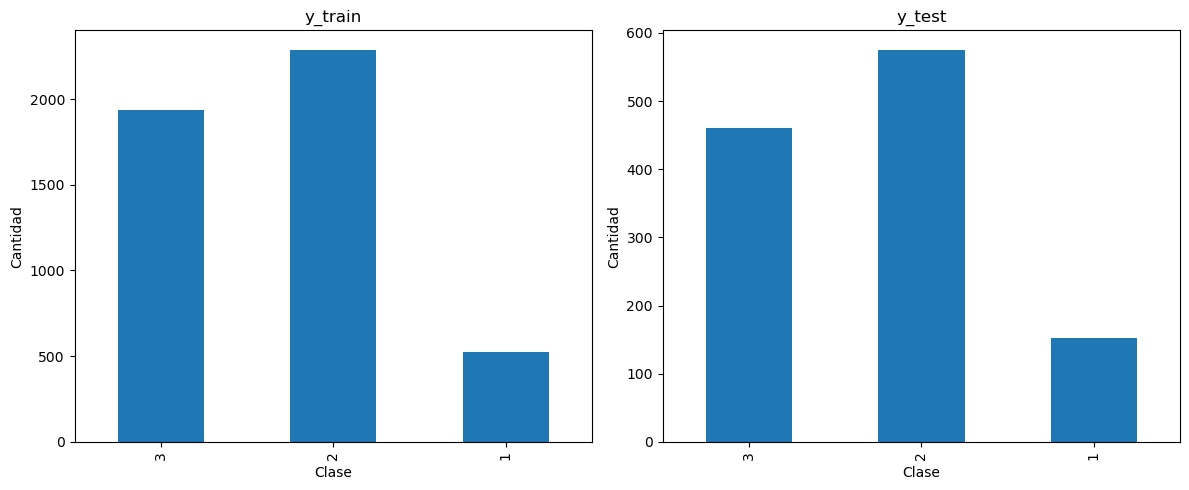

In [113]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0],
    title='y_train'
)

y_test.value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1],
    title='y_test'
)

axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')

axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

**Vamos a tener que aplicar técnicas de balanceo por la diferencia en cantidad de datos en las posibles variables target**


Como vemos abajo la clase 1 (violation) tiene sólo un 11% de las muestras

In [114]:
(y_train.value_counts(normalize=True) * 100).round(2)

LAW_CAT_CD
2    48.14
3    40.81
1    11.05
Name: proportion, dtype: float64

Vamos a tener que generar muestras de los datos 1 y 3 para balancear el dataset

Escalado y balanceo

In [115]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling
ros = RandomOverSampler(random_state=42)

X_train_bal, y_train_bal = ros.fit_resample(
    X_train_scaled,
    y_train
)

print("Antes:")
print(y_train.value_counts())

print("\nDespués:")
print(y_train_bal.value_counts())

Antes:
LAW_CAT_CD
2    2287
3    1939
1     525
Name: count, dtype: int64

Después:
LAW_CAT_CD
3    2287
2    2287
1    2287
Name: count, dtype: int64


# **Punto 6**

**Reducción de dimensionalidad**

* Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase.
* Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción


Hago correlación Kendall Tau porque tenemos varible Target categórica ordinal y queremos buscar la correlación con el resto de las columnas

In [116]:
# Unimos temporalmente X e y
df = X_train.copy()
df["target"] = y_train

# Correlación Kendall de todas las columnas contra el target
kendall_corr = df.corr(method="kendall")["target"].drop("target")

# Ordenamos por valor absoluto
kendall_corr = kendall_corr.reindex(
    kendall_corr.abs().sort_values(ascending=False).index
)

print(kendall_corr)

VIC_AGE_65+                                 0.110498
SUSP_RACE_WHITE                            -0.093280
VIC_RACE_BLACK                             -0.087694
SUSP_RACE_BLACK                            -0.087484
VIC_AGE_25-44                              -0.083180
SUSP_AGE_45-64                             -0.076403
DURATION_STATE                              0.075810
SUSP_RACE_WHITE HISPANIC                   -0.066645
VIC_SEX_F                                  -0.066590
SUSP_AGE_25-44                             -0.065008
CRM_ATPT_CPTD_CD                           -0.059980
VIC_RACE_WHITE                              0.059949
SUSP_AGE_65+                               -0.055062
VIC_RACE_WHITE HISPANIC                    -0.054479
TIME_PERIOD_Morning                         0.047734
VIC_RACE_ASIAN / PACIFIC ISLANDER           0.044864
TIME_PERIOD_Night                          -0.043638
TIME_PERIOD_Early morning                   0.036943
TIME_PERIOD_Afternoon                      -0.

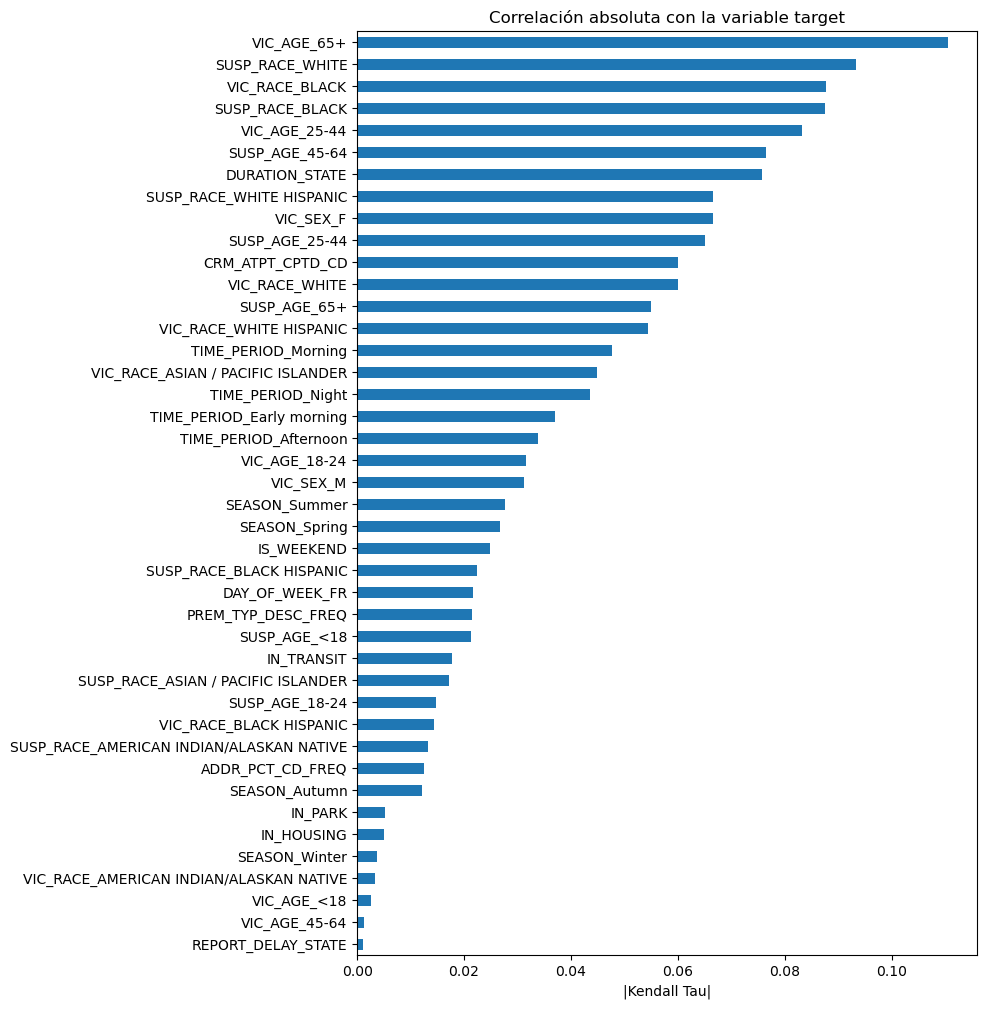

In [117]:
kendall_corr.abs().sort_values().plot(kind="barh", figsize=(8,12))
plt.xlabel("|Kendall Tau|")
plt.title("Correlación absoluta con la variable target")
plt.show()

Voy a descartar las columnas con menos de **0.02**

In [118]:
cols_correlacion_muy_debil = ['IN_TRANSIT' , 'SUSP_RACE_ASIAN / PACIFIC ISLANDER', 'SUSP_AGE_18-24','VIC_RACE_BLACK HISPANIC', 'SUSP_RACE_AMERICAN INDIAN/ALASKAN NATIVE', 'ADDR_PCT_CD_FREQ' ,
                              'SEASON_Autumn','IN_PARK','IN_HOUSING','SEASON_Winter' ,'VIC_RACE_AMERICAN INDIAN/ALASKAN NATIVE','VIC_AGE_<18','VIC_AGE_45-64','REPORT_DELAY_STATE']

X_train=X_train.drop(columns=cols_correlacion_muy_debil)
X_test=X_test.drop(columns=cols_correlacion_muy_debil)

Informción mutua

In [119]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Calcular información mutua
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

# Crear un DataFrame con los resultados
mi_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Mutual Information": mi_scores
})

# Ordenar de mayor a menor
mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

print(mi_df)

                             Variable  Mutual Information
3                      DURATION_STATE            0.025566
27                 PREM_TYP_DESC_FREQ            0.025152
19                      VIC_AGE_25-44            0.010892
6                     SUSP_RACE_BLACK            0.008885
16                       SUSP_AGE_65+            0.007772
20                        VIC_AGE_65+            0.006647
24                  TIME_PERIOD_Night            0.005089
11                     VIC_RACE_BLACK            0.004704
25                      SEASON_Spring            0.004496
22          TIME_PERIOD_Early morning            0.004335
10  VIC_RACE_ASIAN / PACIFIC ISLANDER            0.003909
12                     VIC_RACE_WHITE            0.003587
26                      SEASON_Summer            0.002913
4                           VIC_SEX_F            0.002804
15                     SUSP_AGE_45-64            0.001391
13            VIC_RACE_WHITE HISPANIC            0.000665
5             

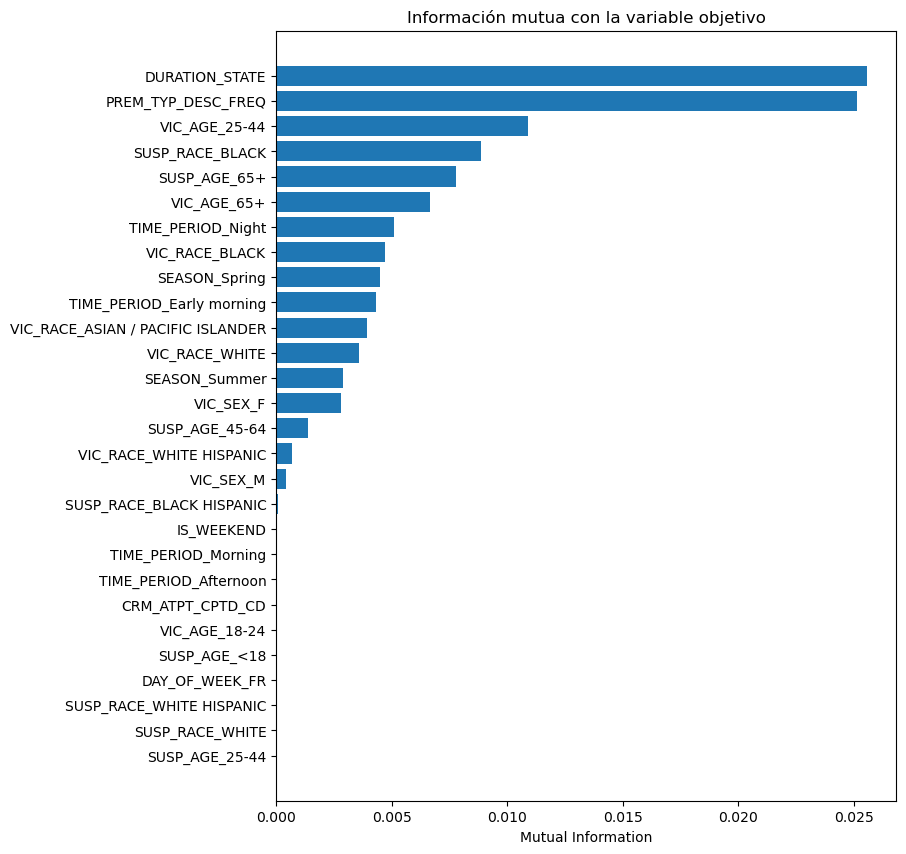

In [120]:
mi_df = mi_df.sort_values("Mutual Information")

plt.figure(figsize=(8,10))
plt.barh(mi_df["Variable"], mi_df["Mutual Information"])
plt.xlabel("Mutual Information")
plt.title("Información mutua con la variable objetivo")
plt.show()

In [121]:
threshold = 0.001

selected_features = mi_df[
    mi_df["Mutual Information"] > threshold
]["Variable"]

print(f"Variables originales: {X_train.shape[1]}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]


print(f"Variables seleccionadas: {len(selected_features)}")

Variables originales: 28
Variables seleccionadas: 15


# **PCA**

Las variables del dataset ya fueron normalizadas y escaladas en el punto 5

[0.55219715 0.08477587 0.06803276 0.05538539 0.04814461 0.04007534
 0.033097   0.02816648 0.02466126 0.01817946 0.01451582 0.01333543
 0.01304111 0.00373761 0.00265472]
[0.55219715 0.63697301 0.70500577 0.76039117 0.80853577 0.84861111
 0.88170811 0.90987459 0.93453584 0.9527153  0.96723113 0.98056656
 0.99360767 0.99734528 1.        ]


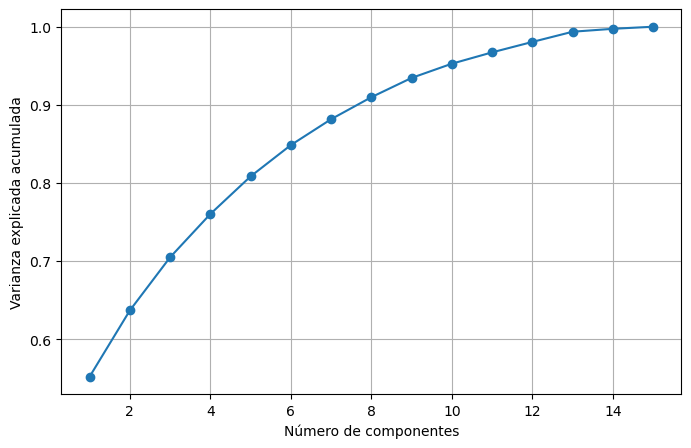

In [122]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train)


varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

print(varianza)
print(varianza_acumulada)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

In [123]:
# Me quedo con 10 componentes que acumula un 95% de la varianza acumulada
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)